In [7]:
# Import Dov's data
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean, circstd
import os
import sys
import pandas as pd
pd.options.mode.chained_assignment = None
import seaborn as sns
import sys,time,random
from joblib import Parallel, delayed

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output.csv").dropna(subset=["min_id","creation"])
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\Bacteria_pairs.csv").dropna(subset=["min_id","creation"])
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\cellPairs_1_10_11_12.csv").dropna(subset=["min_id","creation"])
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\cellPairs_14_15_19.csv").dropna(subset=["min_id","creation"])
# all_pairs_df.fuse_up = all_pairs_df.fuse_up.astype("bool")
# all_pairs_df = all_pairs_df.groupby('plus_id').filter(lambda x: len(x)>5).copy()

def mod_pi(angles):
    # Normalize the angles to [0, 2π]
    angles = angles%(2*np.pi)
    # Shift to [-π, π]
    angles[angles>np.pi] = angles[angles>np.pi]-2*np.pi
    return angles

def polar_to_cart(r, theta, in_degrees=False):
    """
    Convert polar coordinates to Cartesian coordinates for NumPy arrays.

    Parameters:
    r (np.ndarray): Array of radii (distances from the origin).
    theta (np.ndarray): Array of angles (in degrees or radians).
    in_degrees (bool): If True, theta is in degrees; if False, theta is in radians.

    Returns:
    np.ndarray: Array of Cartesian coordinates with shape (n, 2), where n is the number of points.
    """
    if in_degrees:
        theta = np.radians(theta)  # Convert degrees to radians

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return np.column_stack((x, y))  # Combine x and y into a single array

Text(0.5, 1.0, '+1/2 Angle of displacement')

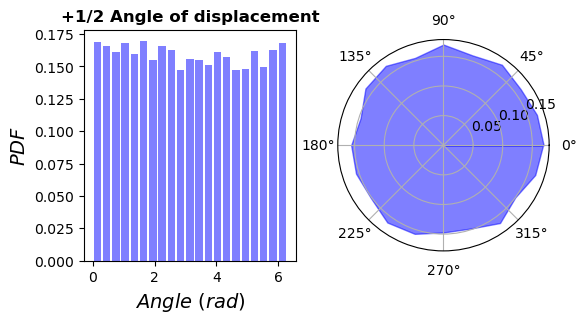

In [3]:
# df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\PlusAndMinusTM6.csv").dropna(subset="TRACK_ID")
df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\HBEC\PlusAndMinusTM_s2.csv").dropna(subset="TRACK_ID")

df_pos = df[df.charge==.5]
df_pos = df_pos.groupby('TRACK_ID').filter(lambda x: len(x)>7).copy()

df_pos["vel_angle"] = np.arctan2(
    df_pos.groupby('TRACK_ID')["POSITION_Y"].diff(periods=3).fillna(0), 
    df_pos.groupby('TRACK_ID')["POSITION_X"].diff(periods=3).fillna(0)
                                )

df_pos = df_pos[df_pos["vel_angle"]!=0]

bins_number = 21  # the [0, 360) interval will be subdivided into this
# number of equal bins
bins = np.linspace(0, 2*np.pi, bins_number+1) 
bins_ = np.linspace(0, 2*np.pi, bins_number) 
width = 2*np.pi / bins_number

fig1 = plt.figure(figsize=(6,3))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')

vel_ang = (df_pos.vel_angle-df_pos.ang1)  % (2*np.pi) 
p1,_,_ = ax1.hist(vel_ang, bins,
                  density=True, rwidth=.8, alpha=.5, color="b")
# ax2.bar(bins_, p1, color="blue", alpha=.4, width=width)
ax2.fill_between(bins_, p1, color="b", alpha=.5)
ax1.set_ylabel("$PDF$", fontsize=14)
ax1.set_xlabel("$Angle ~(rad)$", fontsize=14)
ax1.set_title("+1/2 Angle of displacement", fontweight="bold")

In [3]:
# # df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\PlusAndMinusTM6.csv").dropna(subset="TRACK_ID")
# df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\HBEC\PlusAndMinusTM_s2.csv").dropna(subset="TRACK_ID")
# df_pos = df[df.charge==-.5].copy()
# df_pos = df_pos.groupby('TRACK_ID').filter(lambda x: len(x)>track_len).copy()
# df_pos.groupby('TRACK_ID').apply(calculate_direction).hist(bins=15, alpha=.5)
# df_pos = df[df.charge==.5].copy()
# df_pos = df_pos.groupby('TRACK_ID').filter(lambda x: len(x)>track_len).copy()
# df_pos.groupby('TRACK_ID').apply(calculate_direction).hist(bins=15, alpha=.5)


### Velocity direction of defects realtive to their symmtry axis

Text(0.5, 0, '$Angle ~(rad)$')

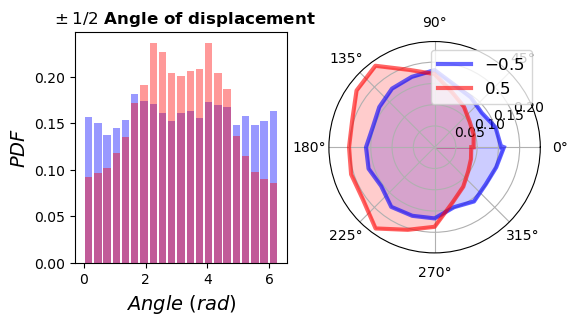

In [13]:
PAIRS = True

if PAIRS:
    df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_bacteria6_all.csv").dropna(subset=["min_id","creation"])
    # df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_HBEC_s23456.csv").dropna(subset=["min_id","creation"])


else:
    df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\PlusAndMinusTM6.csv").dropna(subset="TRACK_ID")
    # df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\HBEC\PlusAndMinusTM_s2.csv").dropna(subset="TRACK_ID")
    xi, yi, id, ang = "POSITION_X","POSITION_Y","TRACK_ID","ang1"


# PARAMETERS
track_len = 6
period = 2

fig = plt.figure(figsize=(6,3))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')
bins_number = 21  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2.*np.pi, bins_number+1) #* 180/np.pi
bins_ = np.linspace(0, 2.*np.pi, bins_number)
width = 2 * np.pi / bins_number

for color,charge in zip(["b","r"],[-.5,.5]):

    if PAIRS and charge==-.5:
        xi, yi, id, ang = "xm","ym","plus_id","angm1"
        df_pos = df.copy()

    elif PAIRS and charge==.5:
        xi, yi, id, ang = "xp","yp","plus_id","angp1"
        df_pos = df.copy()

    else:
        df_pos = df[df.charge==charge].copy()

    df_pos = df_pos.groupby(id).filter(lambda x: len(x)>track_len).copy()

    df_pos["vel_angle"] = np.arctan2(
        df_pos.groupby(id)[yi].diff(periods=period).fillna(0), 
        df_pos.groupby(id)[xi].diff(periods=period).fillna(0)
        )

    df_pos = df_pos[df_pos["vel_angle"]!=0]

    vel_ang = (df_pos.vel_angle - df_pos[ang]) % (2*np.pi)

    p1,_,_ = ax1.hist(vel_ang, bins, 
                      alpha=.4, density=True, rwidth=.8, color=color)
    ax2.plot(bins_, p1, color, linewidth=3, alpha=.6, label="$%s$" % charge)
    ax2.fill_between(bins_, p1, color=color, alpha=.2)
    # break
ax1.set_title("$~\pm1/2$ Angle of displacement", fontweight="bold")
ax2.legend(fontsize=12, loc='best')
ax1.set_ylabel("$PDF$", fontsize=14)
ax1.set_xlabel("$Angle ~(rad)$", fontsize=14)

In [71]:
a = np.array([1,1])
b = np.array([-1,0])
(a @ b) / (np.linalg.norm(a)*np.linalg.norm(b))

-0.7071067811865475

In [157]:
circmean(df_pos.ang1, low=-np.pi, high=np.pi), circstd(df_pos.ang1, low=-np.pi, high=np.pi)

(2.2592981962285137, 2.2483076911636672)

(array([15581.,  5153.,  5550.,  4483.,  7463.,  7442.,  5069.,  6214.,
         5814., 19936.]),
 array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ]),
 <BarContainer object of 10 artists>)

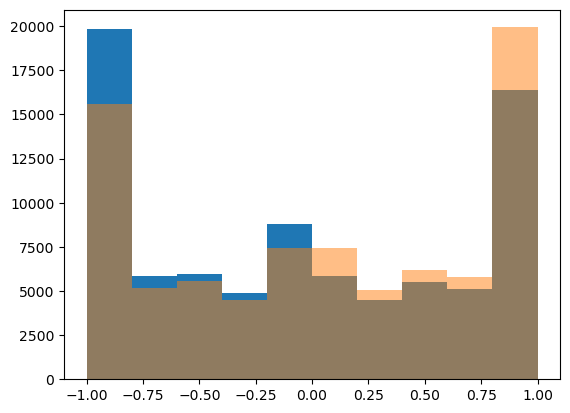

In [158]:
plt.hist(np.cos(df_pos.ang1))
plt.hist(np.sin(df_pos.ang1), alpha=.5)

<AxesSubplot: >

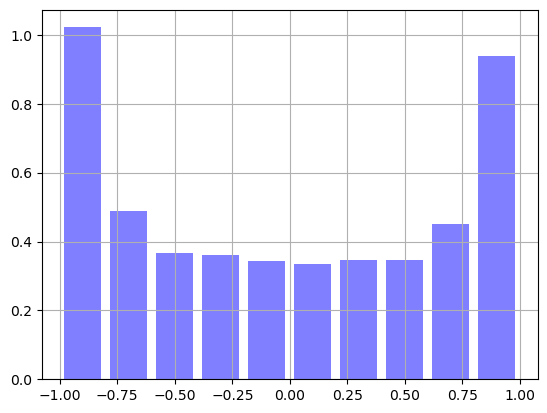

In [144]:
df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\PlusAndMinusTM6.csv").dropna(subset="TRACK_ID")
# df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\HBEC\PlusAndMinusTM_s2.csv").dropna(subset="TRACK_ID")
# 
df_pos = df[df.charge==.5]
df_pos = df_pos.groupby('TRACK_ID').filter(lambda x: len(x)>7).copy()

dd = 1
df_pos["dx"] = df_pos.groupby('TRACK_ID')["POSITION_X"].diff(periods=dd).fillna(0) 
df_pos["dy"] = df_pos.groupby('TRACK_ID')["POSITION_Y"].diff(periods=dd).fillna(0) 
df_pos = df_pos[df_pos["dx"]!=0]

vec_a = df_pos[["dx","dy"]].to_numpy()
vec_b = np.array([np.cos(df_pos.ang1), np.sin(df_pos.ang1)]).T
# vec_b = np.array([np.sin(df_pos.ang1), -np.cos(df_pos.ang1)]).T
df_pos["dr_dot_p"] = np.einsum('ij,ij->i', vec_a, vec_b)

# Compute the magnitudes (norms) of each vector
magnitude_a = np.linalg.norm(vec_a, axis=1)
magnitude_b = np.linalg.norm(vec_b, axis=1)

# Normalize the dot products (cosine similarity)
df_pos["dr_dot_p"] = df_pos["dr_dot_p"] / (magnitude_a * magnitude_b)
df_pos["dr_dot_p"].hist(density=True, rwidth=.8, alpha=.5, color="b")

# bins_number = 15  # the [0, 360) interval will be subdivided into this
# # number of equal bins
# bins = np.linspace(0, np.pi, bins_number+1) 
# bins_ = np.linspace(0, np.pi, bins_number) 
# width = np.pi / bins_number

# fig1 = plt.figure(figsize=(6,3))
# ax1 = plt.subplot(121)
# ax2 = plt.subplot(122, projection='polar')

# vel_ang = np.arccos(df_pos["dr_dot_p"])
# p1,_,_ = ax1.hist(vel_ang, bins,
#                   density=True, rwidth=.8, alpha=.5, color="b")
# # ax2.bar(bins_, p1, color="blue", alpha=.4, width=width)
# ax2.fill_between(bins_, p1, color="b", alpha=.5)
# ax1.set_ylabel("$PDF$", fontsize=14)
# ax1.set_xlabel("$Angle ~(rad)$", fontsize=14)
# ax1.set_title("+1/2 Angle of displacement", fontweight="bold")


In [143]:
import numpy as np

# Define two arrays of 2D vectors
vectors_a = np.array([[1, 0],
                       [3, 4],
                       [5, 6]])

# vectors_b = np.array([[1, 0],
#                        [9, 12],
#                        [11, 12]])
vectors_b = np.array([[0, -1],
                       [12, -9],
                       [12, -11]])

# Compute the dot product for each pair of corresponding vectors
dot_products = np.einsum('ij,ij->i', vectors_a, vectors_b)

# Compute the magnitudes (norms) of each vector
magnitude_a = np.linalg.norm(vectors_a, axis=1)
magnitude_b = np.linalg.norm(vectors_b, axis=1)

# Normalize the dot products (cosine similarity)
normalized_dot_products = dot_products / (magnitude_a * magnitude_b)

# Print the results
print("Dot products of corresponding vectors:")
print(dot_products)
print("Normalized dot products (cosine similarity):")
print(normalized_dot_products)


Dot products of corresponding vectors:
[ 0  0 -6]
Normalized dot products (cosine similarity):
[ 0.          0.         -0.04719146]


(-40.0, 40.0)

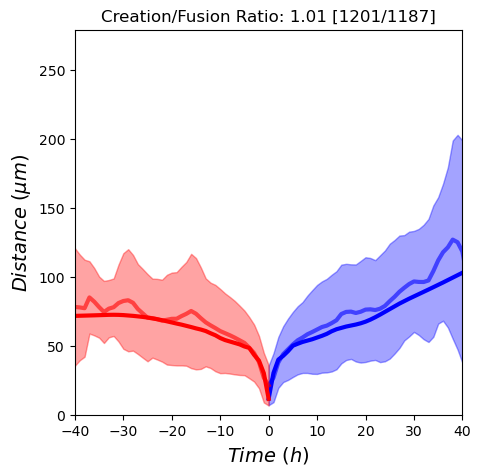

In [279]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean, circstd
import os
import sys
import pandas as pd
import sys
import statsmodels.api as sm
from scipy import stats
sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

%matplotlib inline
fig, ax1 = plt.subplots(1,1,  figsize=(5,5))
show = False
win = 1
track_len = 3

# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_HBEC_s2.csv").dropna(subset=["min_id","creation"])
all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_HBEC_s23456.csv").dropna(subset=["min_id","creation"])
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_RPE1.csv").dropna(subset=["min_id","creation"])
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_C2C12_s2.csv").dropna(subset=["min_id","creation"])
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_bacteria6_right2.csv").dropna(subset=["min_id","creation"])
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_bacteria6_all.csv").dropna(subset=["min_id","creation"])


all_pairs_df.fuse_up = all_pairs_df.fuse_up.astype("bool")
all_pairs_df = all_pairs_df.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()

df_cr = all_pairs_df[all_pairs_df.creation].reset_index().copy()
df_cr["track_frame"] = df_cr.groupby(['plus_id','min_id'])['FRAME'].transform(lambda x: x-x.iloc[0])

df_fuse = all_pairs_df[all_pairs_df.fusion].reset_index().copy()
df_fuse["track_frame"] = df_fuse.groupby(['plus_id','min_id'])['FRAME'].transform(lambda x: x-x.iloc[-1])

df_all = pd.concat([df_cr, df_fuse])


# for color,df in zip(["b","r","k"], [df_cr, df_fuse, df_all]):
for color,df in zip(["b","r"], [df_cr, df_fuse]):    
    df_ = plot_rolling_average(df, ax1, "distance", "track_frame", win=win, show=~show, color=color, avfunc=np.mean, stdfunc=np.std)
    if not show:
        # ax1.plot(df_.track_frame/12, df_.distance_ave*.74, color, linewidth=3)
        ax1.fill_between(df_.track_frame, 
                        (df_.distance_ave-df_.distance_std), 
                        (df_.distance_ave+df_.distance_std),
                        color=color, alpha=.2)
        # break

    df = df.sort_values('track_frame')
    # Apply LOWESS smoothing
    lowess = sm.nonparametric.lowess
    smoothed = lowess(df['distance'], df['track_frame'], frac=1./6.)  # Adjust frac for smoothing level
    # Create a new DataFrame for the smoothed values
    smoothed_df = pd.DataFrame(smoothed, columns=['track_frame', 'smoothed_distance'])
    ax1.plot(smoothed_df['track_frame'], smoothed_df['smoothed_distance'], color=color, linewidth=3, label='Smoothed Distance')


cr_n = len(all_pairs_df.plus_id[all_pairs_df.creation].unique())
fuse_n = len(all_pairs_df.plus_id[all_pairs_df.fusion].unique())

plt.title("Creation/Fusion Ratio: %.4s [%.4s/%.4s]" % (cr_n/fuse_n, cr_n, fuse_n))
ax1.set_xlabel("$Time ~(h)$", fontsize=14); ax1.set_ylabel("$Distance ~(\mu m)$", fontsize=14)
ax1.set_ylim([0,None])
ax1.set_xlim([-40,40])
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\binding ave bacteria.svg")
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\binding ave HBEC.svg")

(-1.8765332028637778,
 2.675857162913955,
 -3.9439384574588536,
 3.9439384574588536)

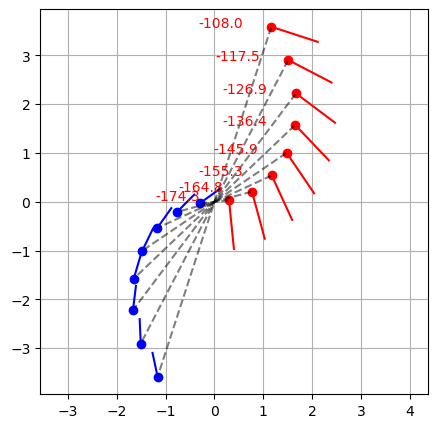

In [153]:
# Parameters for the spiral
theta = np.linspace(.1, np.pi/2.5, 8)  # Angle from 0 to 4π
r = 3*theta  # Radius as a function of theta

# Convert polar coordinates to Cartesian coordinates
px = r * np.cos(theta)
py = r * np.sin(theta)

mx = -px
my = -py 


# Create the plot
plt.figure(figsize=(5, 5))
plt.plot(px, py, 'or')
plt.plot(mx, my, 'ob')

ang = (np.arctan2(my-py, mx-px)) 
angp = ang + np.pi/2
angm = ang + np.pi/2 +2/3*np.pi

px_ = px + np.cos(angp)
py_ = py + np.sin(angp)

mx_ = mx + .5* np.cos(angm)
my_ = my + .5* np.sin(angm)

for i in range(len(ang)):
    plt.plot([px[i], mx[i]], [py[i], my[i]], '--k', alpha=.5)
    plt.text(px[i]-1.5, py[i], "%.1f" % (ang[i]* 180/np.pi), color="r")
    plt.plot([px[i], px_[i]], [py[i], py_[i]], 'r')
    plt.plot([mx[i], mx_[i]], [my[i], my_[i]], 'b')


plt.grid()
plt.axis('equal')

Total rotation (in radians): 19.0


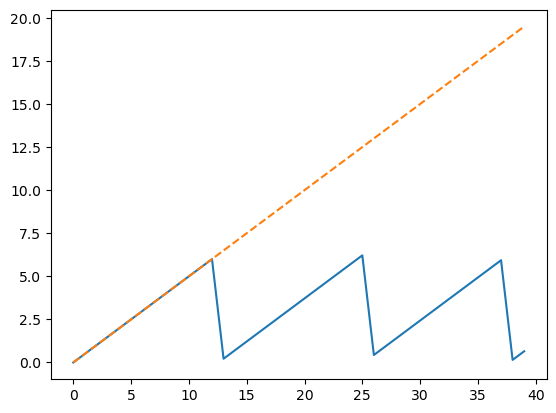

In [189]:
# Example angular position data (in radians)
angular_position = np.arange(0,20,.5) % (2*np.pi) # Example positions
time = np.arange(len(angular_position))  # Time in seconds

angular_position_mod = np.unwrap(angular_position, period=(2*np.pi))

# Calculate angular velocity (difference in position over difference in time)
angular_velocity = np.diff(angular_position_mod) / np.diff(time)

# Integrate angular velocity to get total rotation using the trapezoidal rule
total_rotation = np.trapz(angular_velocity, time[1:])  # time[1:] because angular_velocity is shorter

print("Total rotation (in radians):", total_rotation)
plt.plot(time, angular_position, '-')
plt.plot(time, angular_position_mod, '--')


In [280]:
def find_pair_origin(group, xp='xp', yp='yp', xm='xm', ym='ym', dist='track_frame', fuse=True, dist0=12.):
    group = group.sort_values(by=dist)
    position = (group['distance'] - dist0).abs().idxmin()
    x0 = (group[xp].loc[position] + group[xm].loc[position])/2
    y0 = (group[yp].loc[position] + group[ym].loc[position])/2
    gamma0 = np.arctan2(group[ym].loc[position]-group[yp].loc[position],
                         group[xm].loc[position]-group[xp].loc[position]) 

    group["angp_"] = np.arctan2(group[yp]-y0, group[xp]-x0)
    group["angp_"] = (group["angp_"] - group["angp_"].loc[position]) %(2*np.pi)
    group["angp_"][group["angp_"]>np.pi] = group["angp_"][group["angp_"]>np.pi]-2*np.pi

    group["angm_"] = np.arctan2(group[ym]-y0, group[xm]-x0)
    group["angm_"] = ((group["angm_"] - group["angm_"].loc[position]) + np.pi) %(2*np.pi)
    # group["angm_"][group["angm_"]>np.pi] = group["angm_"][group["angm_"]>np.pi] - 2*np.pi

    # defect pair axis relative to fusion/annhilation axis
    group["gamma"] = np.arctan2(group[ym]-group[yp],
                                group[xm]-group[xp]) %(2*np.pi) #- gamma0) 
    
    group["gamma_rel"] = (group["gamma"] - gamma0) % (2*np.pi)
    group["gamma_rel"][group["gamma_rel"]>np.pi] = group["gamma_rel"][group["gamma_rel"]>np.pi] - 2*np.pi

    group["delta"] = (group["angp1"] - 3*group["angm1"] + 2*group["gamma"] - np.pi) %(2*np.pi)
    group["delta"][group["delta"]>np.pi] = group["delta"][group["delta"]>np.pi] - 2*np.pi

    group["angp1_rel"][group["angp1_rel"]>np.pi] = group["angp1_rel"][group["angp1_rel"]>np.pi] - 2*np.pi

    return group

label = 'track_frame'
# label = 'distance'
dist0 = 15
track_len = 10
df_fuse = df_fuse.groupby(['plus_id','min_id'], group_keys=False).apply(find_pair_origin, xp='xp', yp='yp', xm='xm', ym='ym', dist=label, dist0=dist0).reset_index(drop=True)
df_cr = df_cr.groupby(['plus_id','min_id'], group_keys=False).apply(find_pair_origin, xp='xp', yp='yp', xm='xm', ym='ym', dist=label, dist0=dist0).reset_index(drop=True)
df_fuse = df_fuse.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()
df_cr = df_cr.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()

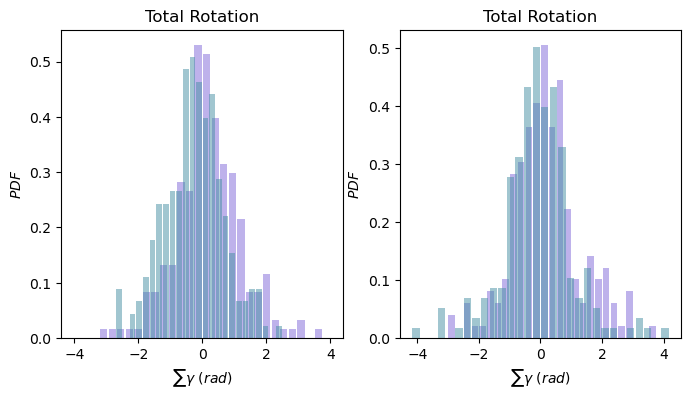

In [172]:
def calculate_total_rotation(group, dist='track_frame'):
    group = group.sort_values(by=dist)
    total_rotation = np.trapz(np.diff(np.unwrap(group["gamma"], period=(2*np.pi))))#/len(group)

    return total_rotation

fig, axs = plt.subplots(1, 2, figsize=(8,4))

dfs = [df_fuse[df_fuse.fuse_up], df_fuse[~df_fuse.fuse_up], df_cr[df_cr.fuse_up],df_cr[~df_cr.fuse_up]]
axs = [axs[0],axs[0],axs[1],axs[1]]; colors = ["#7F66D8","#448FA3","#7F66D8","#448FA3"]

# dfs = [df_fuse, df_cr]
# axs = [axs[0],axs[1]]; colors = ["r","b"]

for ax,color,df in zip(axs,colors,dfs):
    total_rotations = df.groupby(['plus_id','min_id'], group_keys=False).apply(calculate_total_rotation)
    lims = np.std(total_rotations)*3
    p,_,_ = ax.hist(total_rotations.ravel(), bins=np.linspace(-lims, lims, 31), alpha=.5, density=True, rwidth=.85, color=color)
    ax.set_title("Total Rotation")
    ax.set_xlabel("$\sum \gamma ~(rad)$")
    ax.set_ylabel("$PDF$")

(0.0, 36.0)

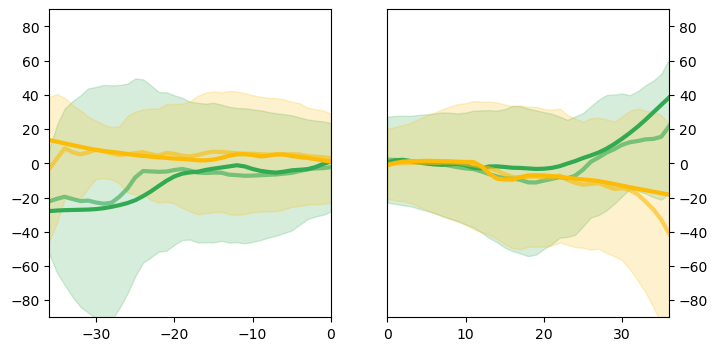

In [287]:
%matplotlib inline

fig, axs = plt.subplots(1, 2, figsize=(8,4))
ylabel = "gamma_rel"#'distance'#"delta" #"angp1_rel"# #"gamma"#"angp_"#"gamma"#
xlabel = 'track_frame'#'distance'#
levels = 10

dfs = [df_fuse[df_fuse.fuse_up], df_fuse[~df_fuse.fuse_up], df_cr[df_cr.fuse_up],df_cr[~df_cr.fuse_up]]
axs_ = [axs[0],axs[0],axs[1],axs[1]]; colors = ["#32a953","#fdbb05","#32a953","#fdbb05"]

# dfs = [df_fuse, df_cr]
# axs_ = [axs[0],axs[1]]; colors = ["r","b"]

for ax, color, df in zip(axs_, 
                         colors, 
                         dfs):
    
    df = df.sort_values(xlabel)
    if len(dfs)>1:
        # Apply LOWESS smoothing
        lowess = sm.nonparametric.lowess
        smoothedp = lowess(df[ylabel], df[xlabel], frac=1./5.)  # Adjust frac for smoothing level
        # Create a new DataFrame for the smoothed values
        smoothed_dfp = pd.DataFrame(smoothedp, columns=[xlabel, 'smoothed_'+ylabel])
        smoothed_dfp['distance'] = df['distance'].values
        ax.plot(smoothed_dfp[xlabel], (smoothed_dfp['smoothed_'+ylabel])*180/np.pi, color=color, linewidth=3, alpha=1.)    

    # sns.kdeplot(data=df, x=xlabel, y=ylabel, ax=ax, levels=levels, alpha=.6, fill=True, color=color)
    win = 3
    plot_rolling_average(df, ax, ylabel, xlabel, win=win, color=color, show=True, std=circstd, low=-np.pi, high=np.pi)


# xlim = 60
# for ax in (axs):
#     ax.set_xlim([-xlim,xlim])
#     # ax.set_xlim([0,100])
#     ax.set_ylim([-np.pi,np.pi])
#     # ax.set_ylim([-180,180])
#     ax.set_box_aspect(1)
#     ax.plot([-xlim,xlim], [0,0], "--k")
#     ax.set_xlabel(label, fontsize=12); ax.set_ylabel(r"$\gamma$", fontsize=12)
axs[1].yaxis.set_label_position("right"),axs[1].yaxis.tick_right()
lims = [-np.pi/2, np.pi/2]
lims = [-90, 90]
axs[0].set_ylim(lims);axs[1].set_ylim(lims)
# axs[0].set_ylim([0,150]);axs[1].set_ylim([0,150])
axs[0].set_xlim([-3*12,0])
axs[1].set_xlim([0,3*12])
# axs[0].set_xlim([-40,0])
# axs[1].set_xlim([0,40])

# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\gammaSTD_cell.svg")
# 


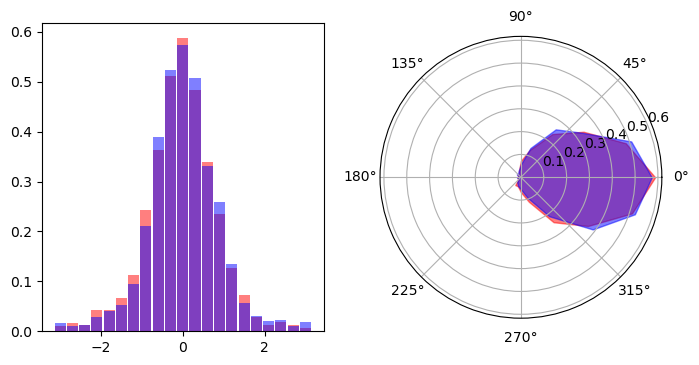

In [167]:
bins_number = 21  # the [0, 360) interval will be subdivided into this
# range_ = [0. 2*np.pi]
range_ = [-np.pi, np.pi]
bins = np.linspace(range_[0], range_[1], bins_number+1) #* 180/np.pi
bins_ = np.linspace(range_[0], range_[1], bins_number)
width =  1.9*np.pi / bins_number

ylabel = "delta"#"gamma"#"angp_"#"gamma"#

fig = plt.figure(figsize=(8,4))
ax1 = plt.subplot(121); ax2 = plt.subplot(122, projection='polar')
# dfs = [df_fuse[df_fuse.fuse_up], df_fuse[~df_fuse.fuse_up]]
# dfs = [df_fuse[~df_fuse.fuse_up], df_cr[~df_cr.fuse_up]]
dfs = [df_fuse, df_cr]
axs_ = [axs[0],axs[1]]; colors = ["r","b"]

for ax,color,df in zip([ax1,ax2], colors, dfs):
    
    p,_,_ = ax1.hist(df[ylabel][(df.track_frame>-15)&(df.track_frame<15)], bins, density=True, rwidth=.9, alpha=.5, color=color); 
    # p,_,_ = ax1.hist(df[ylabel][df.track_frame<-15], bins, density=True, rwidth=.9, alpha=.5, color=color)
    # ax2.bar(bins_, p, width=width, bottom=0., alpha=.6)
    ax2.fill_between(bins_, p, alpha=.5, color=color)


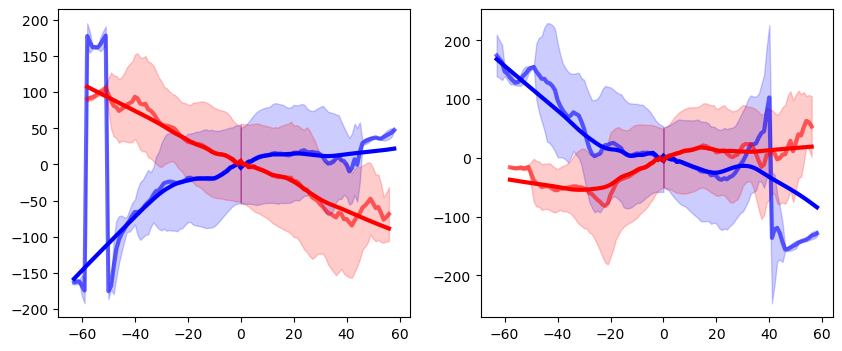

In [8]:
std = True
dfs = [df_fuse[df_fuse.fuse_up], df_fuse[~df_fuse.fuse_up], df_cr[df_cr.fuse_up], df_cr[~df_cr.fuse_up]]
colors = ['b','r','b','r']

radial_dfs_p = []
radial_dfs_m = []

fig, (ax1,ax2) = plt.subplots(1,2,  figsize=(10,4))
for color, df in zip(colors, dfs[:]):
    df = df.sort_values(label)
    dfp_ = plot_rolling_average(df, ax1, "angp_", label, win=2, color=color, show=True, std=circstd, low=-np.pi, high=np.pi)
    dfm_ = plot_rolling_average(df, ax2, "angm_", label, win=2, color=color, show=True, std=circstd, low=-np.pi, high=np.pi)

    # Apply LOWESS smoothing
    lowess = sm.nonparametric.lowess
    smoothedp = lowess((mod_pi(df['angp_'])), df[label], frac=1./5.)  # Adjust frac for smoothing level
    # Create a new DataFrame for the smoothed values
    smoothed_dfp = pd.DataFrame(smoothedp, columns=[label, 'smoothed_angp_'])
    smoothed_dfp['distance'] = df['distance'].values
    smoothed_dfp['angp__std'] = dfp_['angp__std'].values
    ax1.plot(smoothed_dfp[label], (smoothed_dfp['smoothed_angp_'])*(180/np.pi), color=color, linewidth=3)

    smoothed_dfp[["x","y"]] = polar_to_cart(smoothed_dfp['distance'], smoothed_dfp['smoothed_angp_'])
    radial_dfs_p.append(smoothed_dfp)

    smoothedm = lowess(mod_pi(df['angm_']), df[label], frac=1./5.)  # Adjust frac for smoothing level
    # Create a new DataFrame for the smoothed values
    smoothed_dfm = pd.DataFrame(smoothedm, columns=[label, 'smoothed_angm_'])
    smoothed_dfm['distance'] = df['distance'].values
    smoothed_dfm['angm__std'] = dfm_['angm__std'].values
    ax2.plot(smoothed_dfm[label], smoothed_dfm['smoothed_angm_']*(180/np.pi), color=color, linewidth=3)

    smoothed_dfm[["x","y"]] = polar_to_cart(smoothed_dfm['distance'], smoothed_dfm['smoothed_angm_'])
    radial_dfs_m.append(smoothed_dfm)

# xlim = 50
# for ax in (ax1,ax2):
#     ax.set_xlim([-xlim,xlim])
#     # ax.set_xlim([0,100])
#     ax.set_ylim([-180,180]);ax.set_box_aspect(1)
#     ax.plot([-xlim,xlim], [0,0], "--k")
#     ax.set_xlabel(label, fontsize=12); ax.set_ylabel(r"$Angle ~(deg)$", fontsize=12)

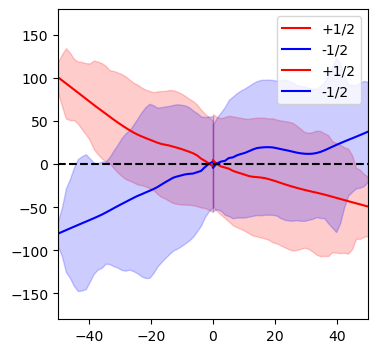

In [6]:
# average up and down configuration
xlim = 50
fig, ax1 = plt.subplots(1,1,  figsize=(4,8))

# FUSION
time = np.linspace(-xlim,0,40)
pang_array = np.zeros_like(time)
pstd_array = np.zeros_like(time)
mang_array = np.zeros_like(time)
mstd_array = np.zeros_like(time)
for i in np.arange(2):
    sign = np.sign(radial_dfs_p[i].smoothed_angp_.mean())
    angle = np.interp(time, radial_dfs_p[i].track_frame, 
                      (radial_dfs_p[i].smoothed_angp_))*180/np.pi
    angle *=sign
    std = np.interp(time, radial_dfs_p[i].track_frame, 
                      radial_dfs_p[i].angp__std)
    pang_array += angle
    pstd_array += std**2

    sign = np.sign(radial_dfs_m[i].smoothed_angm_.mean())
    angle = np.interp(time, radial_dfs_m[i].track_frame, 
                      (radial_dfs_m[i].smoothed_angm_))*180/np.pi
    angle *=sign
    std = np.interp(time, radial_dfs_m[i].track_frame, 
                      radial_dfs_m[i].angm__std)
    mang_array += angle
    mstd_array += std**2    
    # ax1.plot(time, angle,".")
    # ax1.fill_between(time, angle-std, angle+std, alpha=.2)
    # break


ax1.plot(time, pang_array/2,"-r", label=r"+1/2")
ax1.fill_between(time,
                     pang_array/2-(pstd_array/2)**.5, 
                     pang_array/2+(pstd_array/2)**.5,
                    color="r",alpha=.2)
ax1.plot(time, -mang_array/2,"-b", label=r"-1/2")
ax1.fill_between(time,
                     -mang_array/2-(mstd_array/2)**.5, 
                     -mang_array/2+(mstd_array/2)**.5,
                    color="b",alpha=.2)

# CREATION
time = np.linspace(0,xlim,40)
pang_array = np.zeros_like(time)
pstd_array = np.zeros_like(time)
mang_array = np.zeros_like(time)
mstd_array = np.zeros_like(time)
for i in np.arange(2,4):
    sign = np.sign(radial_dfs_p[i].smoothed_angp_.mean())
    angle = np.interp(time, radial_dfs_p[i].track_frame, 
                      (radial_dfs_p[i].smoothed_angp_))*180/np.pi
    angle *=sign
    std = np.interp(time, radial_dfs_p[i].track_frame, 
                      radial_dfs_p[i].angp__std)
    pang_array += angle
    pstd_array += std**2

    sign = np.sign(radial_dfs_m[i].smoothed_angm_.mean())
    angle = np.interp(time, radial_dfs_m[i].track_frame, 
                      (radial_dfs_m[i].smoothed_angm_))*180/np.pi
    angle *=sign
    std = np.interp(time, radial_dfs_m[i].track_frame, 
                      radial_dfs_m[i].angm__std)
    mang_array += angle
    mstd_array += std**2
    # ax1.plot(time, angle,".")
    # ax1.fill_between(time, angle-std, angle+std, alpha=.2)
    # break


ax1.plot(time, -pang_array/2,"-r", label=r"+1/2")
ax1.fill_between(time,
                     -pang_array/2-(pstd_array/2)**.5, 
                     -pang_array/2+(pstd_array/2)**.5,
                    color="r",alpha=.2)
ax1.plot(time, mang_array/2,"-b", label=r"-1/2")
ax1.fill_between(time,
                     mang_array/2-(mstd_array/2)**.5, 
                     mang_array/2+(mstd_array/2)**.5,
                    color="b", alpha=.2)

ax1.set_ylim([-180,180])
ax1.set_xlim([-xlim,xlim])
ax1.plot([-xlim,xlim], [0,0], "--k")
ax1.set_box_aspect(1)
ax1.legend()

# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\pair rotation bacteria.svg") 
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\pair rotation HBEC.svg")

In [7]:
df1 = radial_dfs_p[0]
df2 = radial_dfs_p[1]
df2['y'] = df2['y'][::-1].reset_index(drop=True)
dfp_fuse = pd.concat([df1, df2], ignore_index=True)

df1 = radial_dfs_p[2]
df2 = radial_dfs_p[3]
df2['y'] = df2['y'][::-1].reset_index(drop=True)
dfp_cr = pd.concat([df1, df2], ignore_index=True)

df1 = radial_dfs_m[0]
df2 = radial_dfs_m[1]
df2['y'] = df2['y'][::-1].reset_index(drop=True)
dfm_fuse = pd.concat([df1, df2], ignore_index=True)

df1 = radial_dfs_m[2]
df2 = radial_dfs_m[3]
df2['y'] = df2['y'][::-1].reset_index(drop=True)
dfm_cr = pd.concat([df1, df2], ignore_index=True)

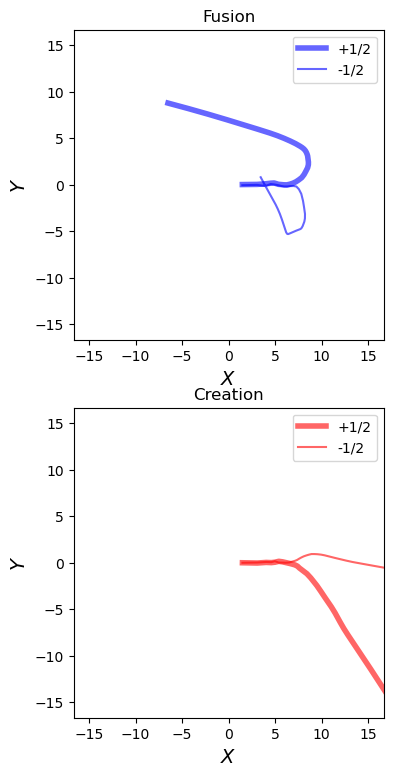

In [8]:
# scale = .74
scale = 150/900

frac = 1/5
colors = ['b','r','--b','--r']

fig, (ax1,ax2) = plt.subplots(2,1,  figsize=(4,9))
# for (i,color),dfp, dfm in zip(enumerate(colors), radial_dfs_p, radial_dfs_m[:]):
for (i,color),dfp, dfm in zip(enumerate(colors), [dfp_fuse, dfp_cr], [dfm_fuse, dfm_cr]):
    dfp[["x","y"]] = polar_to_cart(dfp['distance']*scale, dfp['smoothed_angp_'])
    x_ = lowess(dfp["x"], dfp["track_frame"], frac=frac)
    y_ = lowess(dfp["y"], dfp["track_frame"], frac=frac)  # Adjust frac for smoothing level
    smooth_dfp = pd.DataFrame(np.column_stack((x_[:,1],y_[:,1])), columns=["x", "y"])
    

    dfm[["x","y"]] = polar_to_cart(dfm['distance']*scale, dfm['smoothed_angm_'])
    x_ = lowess(dfm["x"], dfm["track_frame"], frac=frac)
    y_ = lowess(dfm["y"], dfm["track_frame"], frac=frac)  # Adjust frac for smoothing level
    smooth_dfm = pd.DataFrame(np.column_stack((x_[:,1],y_[:,1])), columns=["x", "y"])

    # ax = ax1 if i < 2 else ax2
    ax = ax1 if i < 1  else ax2
    ax.plot(smooth_dfp["x"], smooth_dfp["y"], color, linewidth=4, alpha=.6, label=r"+1/2")
    ax.plot(smooth_dfm["x"], smooth_dfm["y"], color, linewidth=1.5, alpha=.6, label=r"-1/2")


xlim = 100*scale
for ax,title in zip([ax1,ax2],["Fusion","Creation"]):
    ax.set_xlim([-xlim,xlim]); ax.set_ylim([-xlim,xlim])
    ax.set_xlabel(r"$X$",fontsize=14); ax.set_ylabel(r"$Y$",fontsize=14)
    ax.set_box_aspect(1); ax.legend()
    ax.set_title(title)

# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\fuse cr traj bacteria.svg") 
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\fuse cr traj HBEC.svg")    

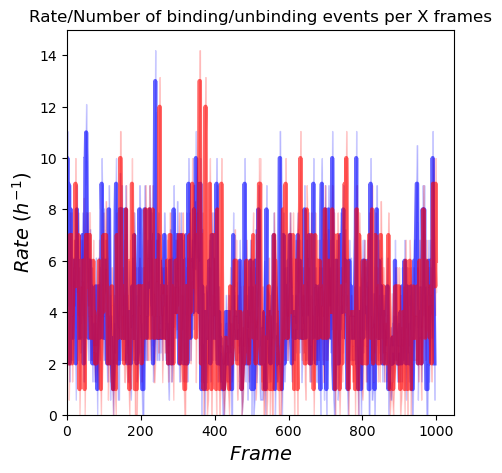

In [13]:
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_HBEC_s2.csv").dropna(subset=["min_id","creation"])
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_RPE1.csv").dropna(subset=["min_id","creation"])
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_C2C12.csv").dropna(subset=["min_id","creation"])
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_bacteria6_right2.csv").dropna(subset=["min_id","creation"])
all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_bacteria6_all.csv").dropna(subset=["min_id","creation"])

all_pairs_df.fuse_up = all_pairs_df.fuse_up.astype("bool")
all_pairs_df = all_pairs_df.groupby(['plus_id','min_id']).filter(lambda x: len(x)>3).copy()

first_appearance  = all_pairs_df.groupby(['plus_id','min_id'])['FRAME'].min().reset_index()
last_appearance  = all_pairs_df.groupby(['plus_id','min_id'])['FRAME'].max().reset_index()

fig, ax1 = plt.subplots(1,1,  figsize=(5,5))
for color,appearance in zip(["b","r"], [first_appearance, last_appearance]):
    # Count occurrences of each frame
    frame_counts = appearance['FRAME'].value_counts().sort_index()
    frame_counts_df = frame_counts.reset_index()
    frame_counts_df.columns = ['frame', 'count']

    plot_rolling_average(frame_counts_df, ax1, "count","frame",  win=1, color=color, avfunc=np.sum, stdfunc=np.mean)

ax1.set_ylim([0, 15])
ax1.set_xlim([0, None])
plt.xlabel('$Frame$', fontsize=14)
plt.ylabel('$Rate ~(h^{-1})$', fontsize=14)
plt.title("Rate/Number of binding/unbinding events per X frames")
os.makedirs(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images", exist_ok=True)
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\pair rate bacteria.svg")
# 

Text(0, 0.5, '$Number ~of ~defects$')

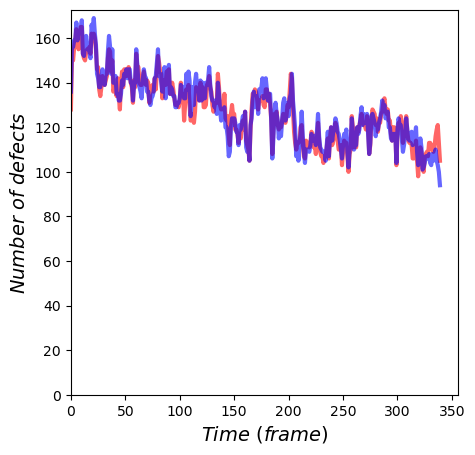

In [16]:
# plus_minus_TM = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\BEER\6\Defects\PlusAndMinusTM.csv").dropna(subset=['TRACK_ID'])
plus_minus_TM = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)\Defects\PlusAndMinusTM.csv").dropna(subset=['TRACK_ID'])
# plus_minus_TM = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\C2C12\PlusAndMinusTM_s19.csv").dropna(subset=['TRACK_ID'])


plus_minus_TM = plus_minus_TM.groupby('TRACK_ID').filter(lambda x : len(x)>3).copy()
dfp = plus_minus_TM[(plus_minus_TM.charge==.5)&(plus_minus_TM.x_img<9000)].groupby('FRAME').count().reset_index()
dfm = plus_minus_TM[(plus_minus_TM.charge==-.5)&(plus_minus_TM.x_img<9000)].groupby('FRAME').count().reset_index()
fig, ax = plt.subplots(1,1,  figsize=(5,5))
ax.plot(dfp.FRAME, dfp.charge, "r", alpha=.6, linewidth=3)
ax.plot(dfm.FRAME, dfm.charge, "b", alpha=.6, linewidth=3)
ax.set_xlim([0, None])
ax.set_ylim([0,None])
ax.set_xlabel(r"$Time ~(frame)$", fontsize=14)
ax.set_ylabel(r"$Number ~of ~defects$", fontsize=14)
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\total def count C2C12 s19.svg")

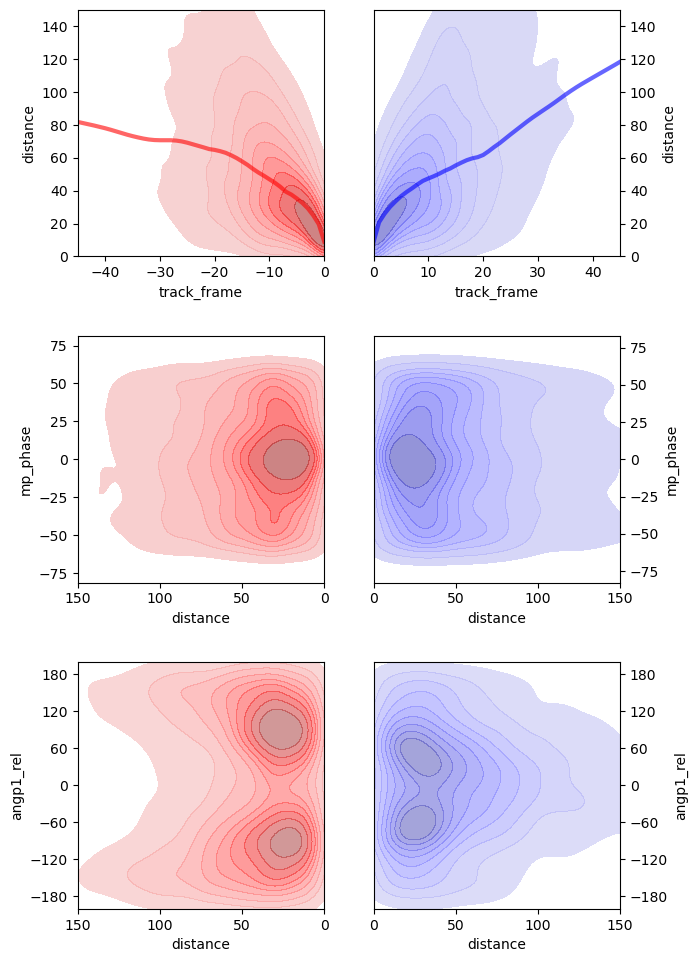

In [81]:
%matplotlib inline
import seaborn as sns

fig, axs = plt.subplots(3, 2, figsize=(7,12))
ax1,ax2,ax3, ax4,ax5,ax6 = axs.ravel()

label = "fusion"
label = "creation"
xrange, trange = 150, 45
track_len = 6

for label, ax_set in zip(["fusion","creation"], [(ax1,ax3,ax5), (ax2,ax4,ax6)]):

    if label=="creation":
        distance_in_time = df_cr.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()
        color = "blue"

    if label=="fusion":
        distance_in_time = df_fuse.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()
        color = "red"

    # distance_in_time.distance = -distance_in_time.distance
    distance_in_time.angp1_rel[distance_in_time.angp1_rel>np.pi] = distance_in_time.angp1_rel[distance_in_time.angp1_rel>np.pi]-(2*np.pi)
    distance_in_time.angp1_rel = distance_in_time.angp1_rel *180/np.pi
    distance_in_time.mp_phase[distance_in_time.mp_phase>(1/3*np.pi)] = distance_in_time.mp_phase[distance_in_time.mp_phase>(1/3*np.pi)]-(2/3*np.pi)
    distance_in_time.mp_phase = distance_in_time.mp_phase *180/np.pi

    # -------   show all  ----------------
    levels = 10
    sns.kdeplot(data=distance_in_time, x="track_frame", y="distance", ax=ax_set[0], levels=levels, color=color, alpha=.6, fill=True)
    sns.kdeplot(data=distance_in_time, x="distance", y="mp_phase", ax=ax_set[1], levels=levels, color=color, alpha=.6, fill=True)
    sns.kdeplot(data=distance_in_time, x="distance", y="angp1_rel", ax=ax_set[2], levels=levels, color=color, alpha=.5, fill=True)

    if label=="fusion":
        [ax.set_box_aspect(1) for ax in ax_set]
        [ax.set_xlim([xrange,0]) for ax in ax_set[1:]]
        ax_set[0].set_xlim([-trange,0]); ax_set[0].set_ylim([0,xrange])

    if label=="creation":
        [(ax.set_box_aspect(1),ax.yaxis.set_label_position("right"),ax.yaxis.tick_right()) for ax in ax_set]
        [ax.set_xlim([0,xrange]) for ax in ax_set[1:]]
        ax_set[0].set_xlim([0,trange]); ax_set[0].set_ylim([0,xrange])

    ax_set[2].set_ylim([-200, 200]); ax_set[2].set_yticks(np.arange(-180, 190, 60))


for ax,color,df in zip([ax1, ax2], ["red","blue",], [df_fuse, df_cr]):    
    # df_ = plot_rolling_average(df, ax, "distance", "track_frame", win=win, show=show, color=color, avfunc=np.mean, stdfunc=np.std)
    # if not show:
    #     ax.plot(df_.track_frame, df_.distance_ave, color, linewidth=3, alpha=.6)
    #     # ax.fill_between(df_.track_frame, 
    #     #                 (df_.distance_ave-df_.distance_std), 
    #     #                 (df_.distance_ave+df_.distance_std),
    #     #                 color=color, alpha=.2)    


    df = df.sort_values('track_frame')
    # Apply LOWESS smoothing
    lowess = sm.nonparametric.lowess
    smoothed = lowess(df['distance'], df['track_frame'], frac=1./6.)  # Adjust frac for smoothing level
    # Create a new DataFrame for the smoothed values
    smoothed_df = pd.DataFrame(smoothed, columns=['track_frame', 'smoothed_distance'])
    ax.plot(smoothed_df['track_frame'], smoothed_df['smoothed_distance'], color=color, alpha=.6, linewidth=3, label='Smoothed Distance')




# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\bacteria_phase.svg")
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\HBEC_phase.svg")

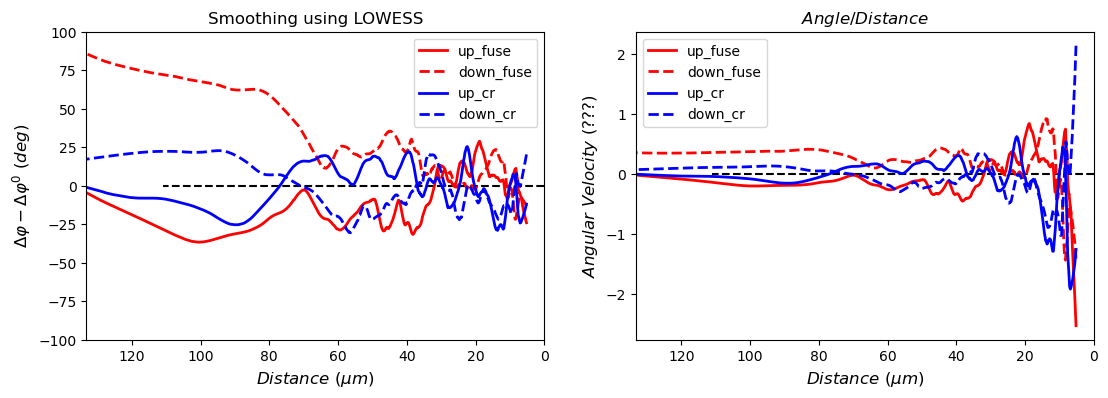

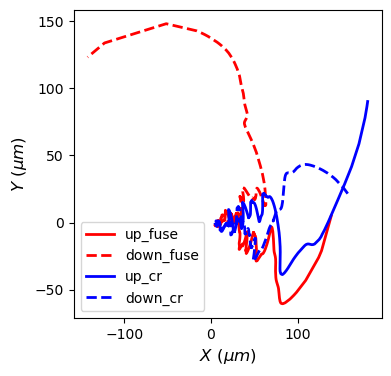

In [375]:
lengthscale = 0.74 # 150/900 # 

ave = 2
df_cr["mp_angle0"] = df_cr.groupby(['plus_id','min_id'])['mp_angle'].transform(lambda x: (x-circmean(x.iloc[:ave]))% (2*np.pi) -np.pi)
df_fuse["mp_angle0"] = df_fuse.groupby(['plus_id','min_id'])['mp_angle'].transform(lambda x: (x-circmean(x.iloc[-ave:]))% (2*np.pi) -np.pi)


track_len = 3
df_fuse1 = df_fuse.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()
df_cr1 = df_cr.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()

fig, (ax1,ax2) = plt.subplots(1,2,  figsize=(13,4))
ax1.plot([0,150* lengthscale], [0,0], "--k", alpha=1)
ax2.plot([0,150* lengthscale], [0,0], "--k", alpha=1)

colors = ["red", "--r", "b","--b"]
labels = ["up_fuse", "down_fuse","up_cr","down_cr"]
dfs = [df_fuse1[~df_fuse1.fuse_up], df_fuse1[df_fuse1.fuse_up], df_cr1[~df_cr1.fuse_up], df_cr1[df_cr1.fuse_up]]

smoothed_dfs = []

for color, label, df in zip(colors,labels, dfs[:]):
    df = df.sort_values('distance')
    # Apply LOWESS smoothing
    lowess = sm.nonparametric.lowess
    smoothed = lowess(df['mp_angle0'], df['distance'], frac=1/10.)  # Adjust frac for smoothing level
    # Create a new DataFrame for the smoothed values
    smoothed_df = pd.DataFrame(smoothed, columns=['distance', 'smoothed_mp_angle'])
    smoothed_dfs.append(smoothed_df)

    # Plotting the original and smoothed data    
    # plt.plot(df['distance'], df['mp_angle0']* 180/np.pi, alpha=0.2)
    ax1.plot(smoothed_df['distance']*lengthscale, smoothed_df['smoothed_mp_angle']* 180/np.pi, 
                color, linewidth=2, label=label)
    
    ang_vel = smoothed_df['smoothed_mp_angle']*180/np.pi / smoothed_df['distance']*lengthscale
    ax2.plot(smoothed_df['distance']*lengthscale, ang_vel, 
            color, linewidth=2, label=label)

ylim = 100
ax1.set_ylim([-ylim,ylim])
ax1.set_xlim([180* lengthscale,0])
ax1.set_xlabel(r'$Distance ~(\mu m)$', fontsize=12)
ax1.set_ylabel(r'$\Delta \varphi - \Delta \varphi^0 ~(deg)$', fontsize=12)
ax1.set_title('Smoothing using LOWESS')
ax1.legend()

ylim = 0.1
# ax2.set_ylim([-ylim,ylim])
ax2.set_xlim([180* lengthscale,0])
ax2.set_xlabel(r'$Distance ~(\mu m)$', fontsize=12)
ax2.set_ylabel(r'$Angular ~Velocity ~(???)$', fontsize=12)
ax2.set_title(r'$Angle/Distance$')
ax2.legend()
def polar_to_cartesian(r, theta):
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

# lengthscale =  150/900 # 0.74 #

fig, ax1 = plt.subplots(1,1,  figsize=(4,4))

for color,label,df in zip(colors, labels, smoothed_dfs):
    # Apply the conversion
    df['x'], df['y'] = polar_to_cartesian(df.distance*lengthscale, df.smoothed_mp_angle)    
    ax1.plot(df['x'], df['y'], color, linewidth=2, label=label) #c=smoothed_df.distance, cmap="jet")

ax1.set_box_aspect(1) 
ax1.set_xlabel(r'$X ~(\mu m)$', fontsize=12)
ax1.set_ylabel(r'$Y ~(\mu m)$', fontsize=12)
ax1.legend()

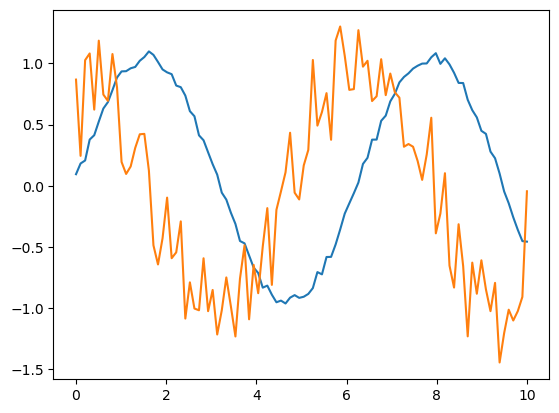

In [388]:
import pandas as pd
import numpy as np

# Sample DataFrame creation (replace this with your actual DataFrame)
df = pd.DataFrame({
    'time_frame': np.linspace(0, 10, 100),  # Example time data
    'distance': np.sin(np.linspace(0, 10, 100)) + .1*np.random.rand(100) # Example distance data
})

# Assuming df is your DataFrame with 'distance' and 'time_frame'
# Replace the above sample DataFrame with your actual DataFrame

# Calculate the time step (assuming uniform spacing)
h = df['time_frame'].diff().mean()  # Average time step

# Initialize a new column for the derivative
df['distance_derivative'] = np.nan

# Apply the five-point stencil method
for i in range(2, len(df) - 2):
    df['distance_derivative'].iloc[i] = (
        -df['distance'].iloc[i + 2] +
        8 * df['distance'].iloc[i + 1] -
        8 * df['distance'].iloc[i - 1] +
        df['distance'].iloc[i - 2]
    ) / (12 * h)

# Handle the edges (first two and last two points) if needed
# You can use forward and backward differences for the edges
# Forward difference for the first two points
for i in range(2):
    df['distance_derivative'].iloc[i] = (
        df['distance'].iloc[i + 1] - df['distance'].iloc[i]
    ) / h

# Backward difference for the last two points
for i in range(2):
    df['distance_derivative'].iloc[-(i + 1)] = (
        df['distance'].iloc[-(i + 1)] - df['distance'].iloc[-(i + 2)]
    ) / h

# Display the DataFrame with the derivative
plt.plot(df.time_frame, df.distance)
plt.plot(df.time_frame, df.distance_derivative)


Text(0, 0.5, '$\\Delta \\theta, ~Angle ~change ~(deg)$')

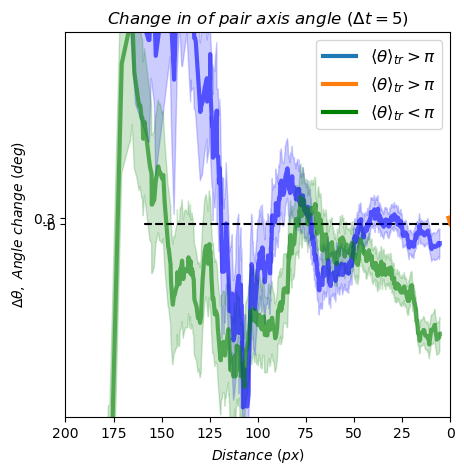

In [228]:
%matplotlib inline
win = 10
diff_period = 5
df = df_fuse.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy().set_index("distance")

dtheta_up = df["mp_angle"][df.fuse_up].diff(periods=diff_period).dropna()# % (2*np.pi)
dtheta_up = dtheta_up.reset_index()
dtheta_down = df["mp_angle"][~df.fuse_up].diff(periods=diff_period).dropna()
dtheta_down = dtheta_down.reset_index()

fig, ax1 = plt.subplots(1,1,  figsize=(5,5))
ax1.plot([0,160], [0,0], "--k", alpha=1)
# ax1.plot(dtheta_up.distance, (dtheta_up.mp_angle)*180/np.pi, "ob", alpha=.05)
# ax1.plot(dtheta_down.distance, (dtheta_down.mp_angle)*180/np.pi, "og", alpha=.05)

ax1.plot([0,0],[0,0], "-b", linewidth=3, label=r"$\langle \theta \rangle _{tr} > \pi$")
ax1.plot([0,0],[0,0], "-g", linewidth=3, label=r"$\langle \theta \rangle _{tr} < \pi$")

df_av_up = plot_rolling_average(dtheta_up, ax1, "mp_angle", "distance", win=win, color="b", low=-np.pi, high=np.pi)
df_av_down = plot_rolling_average(dtheta_down, ax1, "mp_angle", "distance", win=win, color="g", low=-np.pi, high=np.pi)

# ax1.invert_xaxis()
ylim = 30
ax1.set_box_aspect(1) 
ax1.set_ylim([-ylim,ylim])
ax1.set_xlim([200,0])
plt.legend(fontsize=12); plt.title(r"$Change ~in ~of ~pair ~axis ~angle ~(\Delta t=%s)$" % diff_period)
plt.xlabel("$Distance ~(px)$"); plt.ylabel(r"$\Delta \theta, ~Angle ~change ~(deg)$")

In [1]:
# Sample DataFrame with angles included
data = {
    'plus_id': [1, 1, 2, 2],
    'xp': [1, 2, 3, 4],
    'yp': [1, 2, 3, 4],
    'theta': [np.pi/4, np.pi/4, np.pi/2, np.pi/2]  # Rotation angles in degrees for each point
}
df = pd.DataFrame(data)

def rotate_points(group, x_col='x_position', y_col='y_position', rot_ang='theta', fuse=True):
    ave = 6
    # Get the angle for the current plus_id from the first row
    if fuse:
        theta = circmean(group[rot_ang].iloc[-ave:]) # Get angle for the first row in the group
        # Get the origin
        ox = np.median(group[x_col].iloc[-ave:])
        oy = np.median(group[y_col].iloc[-ave:])
    
    else:
        theta = circmean(group[rot_ang].iloc[:ave])
        # Get the origin
        ox = np.median(group[x_col].iloc[:ave])
        oy = np.median(group[y_col].iloc[:ave])

    translated_x = group[x_col] - ox
    translated_y = group[y_col] - oy

    # Create rotation matrix
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                 [np.sin(theta), np.cos(theta)]])    
    # Apply rotation to each point
    rotated_points = np.column_stack((translated_x, translated_y)) @ rotation_matrix.T
    
    # Create new columns for rotated coordinates
    group[f'{x_col}_rotated'] = rotated_points[:, 0]
    group[f'{y_col}_rotated'] = rotated_points[:, 1]
    
    return group

# Group by 'plus_id' and apply the rotation function
# df_rotated = df.groupby('plus_id', group_keys=False).apply(rotate_points, x_col='xp', y_col='yp', rot_ang='theta', fuse=False).reset_index(drop=True)

# print(df_rotated)

df_cr1 = df_cr1.groupby(['plus_id','min_id'], group_keys=False).apply(rotate_points, x_col='xp', y_col='yp', rot_ang='mp_angle').reset_index(drop=True)
df_cr1 = df_cr1.groupby(['plus_id','min_id'], group_keys=False).apply(rotate_points, x_col='xm', y_col='ym', rot_ang='mp_angle').reset_index(drop=True)


NameError: name 'np' is not defined

In [124]:
df_cr1[~df_cr1.fuse_up].groupby(['plus_id', 'min_id']).ngroups

411

In [125]:
# Group by 'plus_id' and 'min_id'
grouped = df_cr1[~df_cr1.fuse_up].groupby(['plus_id', 'min_id'])
count = 0
# Prepare a DataFrame to store the average trajectory
average_trajectory = pd.DataFrame()

# Interpolate and average trajectories
for (plus_id, min_id), group in grouped:
    if count>10:
        break
    # Sort by time
    group = group.sort_values('distance')    
    # Interpolate to a common time grid
    time_grid = np.linspace(group['distance'].min(), group['distance'].max(), num=30)  # 100 points
    xp_interp = np.interp(time_grid, group['distance'], group['xp_rotated'])
    yp_interp = np.interp(time_grid, group['distance'], group['yp_rotated'])
    
    # Create a DataFrame for the interpolated trajectory
    interp_df = pd.DataFrame({'distance': time_grid, 'xp_rotated': xp_interp, 'yp_rotated': yp_interp})
    
    # Append to the average trajectory DataFrame
    average_trajectory = pd.concat([average_trajectory, interp_df], ignore_index=True)
    # Plot the original trajectories

    # plt.plot(group['xp_rotated'], group['yp_rotated'], label=f'Trajectory ID: {plus_id}-{min_id}')
    plt.plot(xp_interp, yp_interp, marker='o', label=f'Trajectory ID: {plus_id}-{min_id}')
    count+=1


# # Calculate the average trajectory
# average_xp = average_trajectory.groupby('distance')['xp_rotated'].mean()
# average_yp = average_trajectory.groupby('distance')['yp_rotated'].mean()

# # Create a plot
# plt.figure(figsize=(10, 6))


# # Plot the average trajectory
# plt.plot(average_xp, average_yp, 'o', alpha=.1, linewidth=2)



In [85]:
df_cr1.plot.scatter("xp_rotated", "yp_rotated", alpha=.1)
# df_cr1.plot.scatter("yp_rotated", "distance", alpha=.1)

<AxesSubplot: xlabel='xp_rotated', ylabel='yp_rotated'>

In [66]:
fig, ax1 = plt.subplots(1,1,  figsize=(5,5))
xp_av = plot_rolling_average(df_cr1, ax1, "distance", "xp_rotated", win=1, show=True, color="red", avfunc=np.mean, stdfunc=np.std)
yp_av = plot_rolling_average(df_cr1, ax1, "distance", "yp_rotated", win=1, show=True, color="blue", avfunc=np.mean, stdfunc=np.std)
xm_av = plot_rolling_average(df_cr1, ax1, "distance", "xm_rotated", win=1, show=True, color="magenta", avfunc=np.mean, stdfunc=np.std)
ym_av = plot_rolling_average(df_cr1, ax1, "distance", "ym_rotated", win=1, show=True, color="cyan", avfunc=np.mean, stdfunc=np.std)



In [61]:
ax1.plot(df_.distance_ave, df_.xp_rotated, "r", linewidth=3)

In [68]:
plt.plot(df_.distance_ave, df_.xp_rotated, "r", linewidth=3)

,yp_rotated,distance_ave,distance_std,distance_count
3772,-264.255563,73.142103,0.00000,73.142103
3773,-253.278814,72.312855,0.00000,72.312855
3774,-246.234717,54.973404,0.00000,54.973404
3775,-227.025407,46.747025,0.00000,46.747025
3776,-216.171077,27.616853,0.00000,27.616853
...,...,...,...,...
6115,181.193033,28.636914,6.43287,57.273827
6116,181.383730,28.636914,6.43287,57.273827
6114,184.811773,25.328177,0.00000,25.328177
6113,190.049187,23.379856,0.00000,23.379856


In [67]:
xp_av

,xp_rotated,distance_ave,distance_std,distance_count
3627,-176.709149,5.492317,0.000000,5.492317
4954,-165.272382,8.701553,0.000000,8.701553
6112,-159.095383,5.844964,0.000000,5.844964
4955,-157.456569,34.021611,0.000000,34.021611
5833,-154.636134,18.560701,15.632151,55.682103
...,...,...,...,...
408,170.660171,31.235334,5.833326,62.470667
410,170.970348,31.235334,5.833326,62.470667
409,172.636574,39.419110,0.000000,39.419110
403,175.000051,30.350630,0.000000,30.350630


In [55]:
%matplotlib qt
plt.plot(df_cr1.xp_rotated, df_cr1.yp_rotated, ".r", alpha=.1)
plt.plot(df_cr1.xm_rotated, df_cr1.ym_rotated, ".b", alpha=.1)

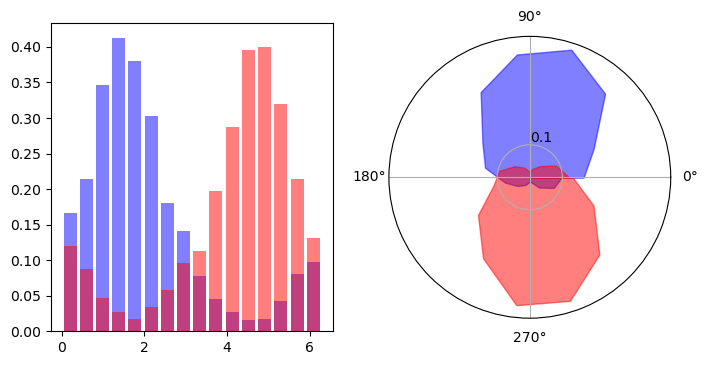

In [24]:
%matplotlib inline
dist = 70
track_len = 3
bins_number = 16  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2*np.pi, bins_number+1) #* 180/np.pi
bins_ = np.linspace(0, 2*np.pi, bins_number)
width =  1.9*np.pi / bins_number

# df_all = plus_minus_df[plus_minus_df.fuse_up & plus_minus_df.creation].copy()

df_fuse1 = df_fuse.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()
df_cr1 = df_cr.groupby(['plus_id','min_id']).filter(lambda x: len(x)>track_len).copy()

# df_all = [
#           df_cr1.angp1_rel[df_cr1.distance<dist].copy() % (2*np.pi),
#           df_fuse1.angp1_rel[df_fuse1.distance<dist].copy() % (2*np.pi),
# #           ]
df_all = [
          df_fuse1.angp1_rel[(df_fuse1.fuse_up) & (df_fuse1.distance<dist)].copy() % (2*np.pi),
          df_fuse1.angp1_rel[(~df_fuse1.fuse_up) & (df_fuse1.distance<dist)].copy() % (2*np.pi),
          ]
# df_all = [
#           df_cr1.angp1_rel[(df_cr1.fuse_up) & (df_cr1.distance<dist)].copy() % (2*np.pi),
#           df_cr1.angp1_rel[(~df_cr1.fuse_up) & (df_cr1.distance<dist)].copy() % (2*np.pi),
#           ]

fig = plt.figure(figsize=(8,4))
ax1 = plt.subplot(121); ax2 = plt.subplot(122, projection='polar')

for color, y in zip(["b","r"], df_all):
    p,_,_ = ax1.hist(y, bins, alpha=.5, density=True, rwidth=.8, color=color)
    # ax2.bar(bins_, p, color=color, width=width, bottom=0., alpha=.6)
    ax2.fill_between(bins_, p, color=color, alpha=.5)
    ax2.set_rgrids(np.arange(.1,.18,.3), angle=90); ax2.set_thetagrids([0,90,180,270])

# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\bacteria pdef fuse create.svg")
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\HBEC pdef fuse create.svg")
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\bacteria plus create.svg")
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\HBEC plus fuse.svg")

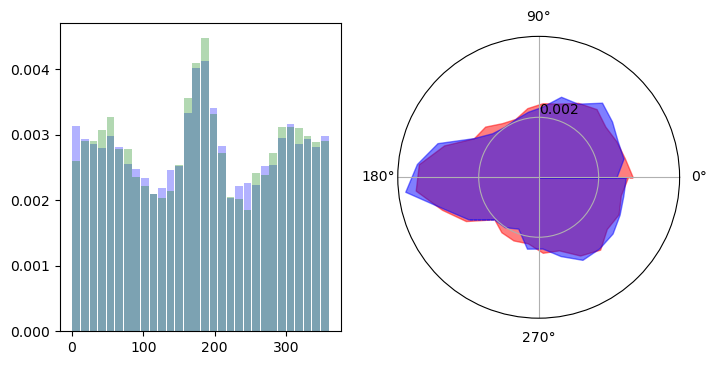

In [27]:
%matplotlib inline
dist = 70

bins_number = 30  # the [0, 360) interval will be subdivided into this
# number of equal bins
bins = np.linspace(0, 2*np.pi, bins_number+1)
bins_ = np.linspace(0, 2*np.pi, bins_number)
width = 2 * np.pi / bins_number

m_ang_cr, m_ang_fuse= [], []
for i in range(3):
    m_ang_fuse.append(df_fuse["angm"+str(i+1)+"_rel"][df_fuse["distance"]<dist].values)   
    m_ang_cr.append(df_cr["angm"+str(i+1)+"_rel"][df_cr["distance"]<dist].values)   

m_ang_fuse = np.concatenate(m_ang_fuse)     
m_ang_cr = np.concatenate(m_ang_cr)  

fig1 = plt.figure(figsize=(8,4))
ax1 = plt.subplot(121); ax2 = plt.subplot(122, projection='polar')


p1,_,_ = ax1.hist((m_ang_fuse % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="b")

p2,_,_ = ax1.hist((m_ang_cr % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="g")

ax2.fill_between(bins_, p1, color="r", alpha=.5)
ax2.fill_between(bins_, p2, color="b", alpha=.5)
ax2.set_rgrids(np.arange(.002,.005,.003), angle=90); ax2.set_thetagrids([0,90,180,270])


fig1.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\bHBEC_minus_hist.svg")


Text(0.5, 1.0, 'dist>70')

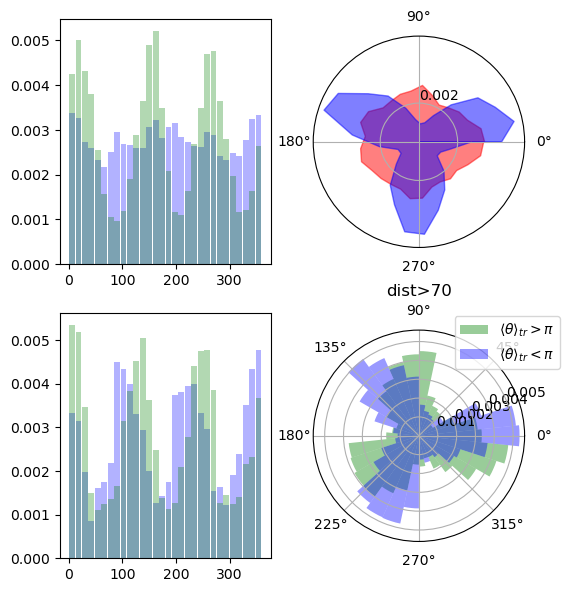

In [9]:
%matplotlib inline
df_all = df_fuse
# df_all = df_all.groupby('plus_id').filter(lambda x: len(x)>10).copy()
dist = 70

bins_number = 30  # the [0, 360) interval will be subdivided into this
# number of equal bins
bins = np.linspace(0, 2*np.pi, bins_number+1)
bins_ = np.linspace(0, 2*np.pi, bins_number)
width = 2 * np.pi / bins_number

m_ang = []
m_ang_up_close, m_ang_down_close = [], []
m_ang_up_far, m_ang_down_far = [], []
for i in range(3):
    m_ang.append(df_all["angm"+str(i+1)+"_rel"][df_all["distance"]<dist].values)   

    m_ang_up_close.append(df_all["angm"+str(i+1)+"_rel"][np.logical_and(
        df_all["fuse_up"], df_all["distance"]<dist)].values)
    m_ang_down_close.append(df_all["angm"+str(i+1)+"_rel"][np.logical_and(
        ~df_all["fuse_up"], df_all["distance"]<dist)].values)
    m_ang_up_far.append(df_all["angm"+str(i+1)+"_rel"][np.logical_and(
        df_all["fuse_up"], df_all["distance"]>dist)].values)
    m_ang_down_far.append(df_all["angm"+str(i+1)+"_rel"][np.logical_and(
        ~df_all["fuse_up"], df_all["distance"]>dist)].values)
    # break

m_ang = np.concatenate(m_ang)     
m_ang_up_close = np.concatenate(m_ang_up_close) 
m_ang_down_close = np.concatenate(m_ang_down_close) 
m_ang_up_far = np.concatenate(m_ang_up_far) 
m_ang_down_far = np.concatenate(m_ang_down_far) 

fig1 = plt.figure(figsize=(6,7))
ax1 = plt.subplot(221)
ax2 = plt.subplot(222, projection='polar')
ax3 = plt.subplot(223)
ax4 = plt.subplot(224, projection='polar')

# p1,_,_ = ax1.hist((m_ang_up_close % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak
p1,_,_ = ax1.hist((m_ang % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="b")
# p1,_,_ = ax1.hist((m_ang_up_close % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
#                     density=True, rwidth=.9, alpha=.3, color="b")

# p2,_,_ = ax1.hist(360-(-m_ang_down_close % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak
p2,_,_ = ax1.hist((m_ang_down_close % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="g")

ax2.fill_between(bins_, p1, color="r", alpha=.5)
ax2.fill_between(bins_, p2, color="b", alpha=.5)
ax2.set_rgrids(np.arange(.002,.005,.003), angle=90); ax2.set_thetagrids([0,90,180,270])
# ax2.bar(bins[:bins_number], p1, color="green", width=width, bottom=0.0, alpha=.4,
#                     label=r"$\langle \theta \rangle _{tr} > \pi$")
# ax2.bar(bins[:bins_number], p2, color="blue", width=width, bottom=0.0, alpha=.4,
#                     label=r"$\langle \theta \rangle _{tr} < \pi$")
# ax2.legend(bbox_to_anchor=(1.2, 1.1)); ax2.set_title("dist<%s" % dist)

# p3,_,_ = ax3.hist((m_ang_up_far % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak
p3,_,_ = ax3.hist((m_ang_up_far % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="b")

# p4,_,_ = ax3.hist(360-(-m_ang_down_far % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak
p4,_,_ = ax3.hist(m_ang_down_far % (2*np.pi)*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="g")

ax4.bar(bins[:bins_number], p3, color="green", width=width, bottom=0.0, alpha=.4,
                    label=r"$\langle \theta \rangle _{tr} > \pi$")
ax4.bar(bins[:bins_number], p4, color="blue", width=width, bottom=0.0, alpha=.4,
                    label=r"$\langle \theta \rangle _{tr} < \pi$")
ax4.legend(bbox_to_anchor=(1.2, 1.1)); ax4.set_title("dist>%s" % dist)

# fig1.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\HBEC_minus_hist_cr.svg")


Text(0, 0.5, '$Angle$')

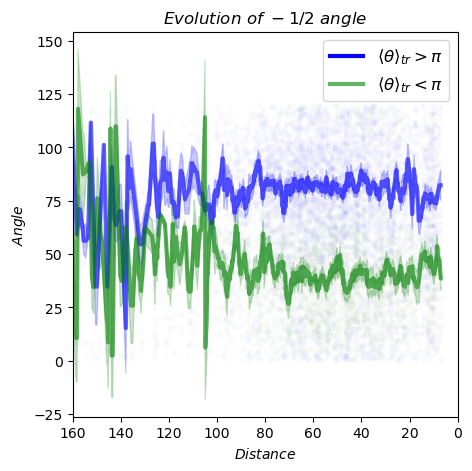

In [35]:
%matplotlib inline                 

df_all = df_cr
df_all = df_all.groupby('plus_id').filter(lambda x: len(x)>10).copy()
win = 1

fig, ax1 = plt.subplots(1,1,  figsize=(5,5))

for i in range(3):
    y_up = df_all["angm"+str(i+1)+"_rel"][df_all["fuse_up"]] % (2/3*np.pi)
    y_down = df_all["angm"+str(i+1)+"_rel"][~df_all["fuse_up"]] % (2/3*np.pi)
    ax1.plot(df_all.distance[df_all["fuse_up"]], y_up*180/np.pi, ".b", alpha=.01)
    ax1.plot(df_all.distance[~df_all["fuse_up"]], (y_down*180/np.pi), ".g", alpha=.01)

m_ang_all = []
for i in range(3):
    m_ang_all.append(df_all["angm"+str(i+1)+"_rel"].values)
    # break
    
df_all["angm_rel_all"] = circmean(np.array(m_ang_all) % (2/3*np.pi), axis=0) % (2/3*np.pi)

df = df_all[df_all["fuse_up"]]
df_av_up = plot_rolling_average(df, ax1, "angm_rel_all", "distance", win=win, color="b", high=2/3*np.pi)
ax1.plot([0,0],[0,0], "-b", linewidth=3, label=r"$\langle \theta \rangle _{tr} > \pi$")
      

df = df_all[~df_all["fuse_up"]]
df_av_down = plot_rolling_average(df, ax1, "angm_rel_all", "distance", show=False, win=win, color="g", high=2/3*np.pi)
# flip to negative values to show divergence
ax1.plot(df_av_down["distance"], df_av_down["angm_rel_all_ave"], "-", color="g", alpha=.6, linewidth=3,
         label=r"$\langle \theta \rangle _{tr} < \pi$")
ax1.fill_between(df_av_down.distance, 
                 (df_av_down["angm_rel_all_ave"])-df_av_down["angm_rel_all_std"]/df_av_down["angm_rel_all_count"]**.5, 
                 (df_av_down["angm_rel_all_ave"])+df_av_down["angm_rel_all_std"]/df_av_down["angm_rel_all_count"]**.5, 
                 color="g", alpha=.2)

plt.xlim([0,160]); 
# plt.ylim([-70,70]); 
# plt.yticks(np.arange(-60, 61, 30))
plt.gca().set_box_aspect(1); plt.gca().invert_xaxis()
plt.legend(fontsize=12); plt.title("$Evolution ~of ~-1/2 ~angle$")
plt.xlabel("$Distance$"); plt.ylabel("$Angle$")    

In [25]:
low,high = 40, 50
np.mean(df_av_down[(df_av_down.distance<high)&(df_av_down.distance>low)]), 25/1000**.5

c:\Users\victo\miniconda3\envs\cellpose\lib\site-packages\numpy\core\fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


(distance              45.171909
 angm_rel_all_ave      30.142888
 angm_rel_all_std      33.052893
 angm_rel_all_count    24.196092
 dtype: float64,
 0.7905694150420949)

In [26]:
grouped = df_all.groupby('plus_id')["angp1_rel"]
df_all["fuse_up"] = grouped.transform(lambda x: circmean(x)>np.pi)

<BarContainer object of 45 artists>

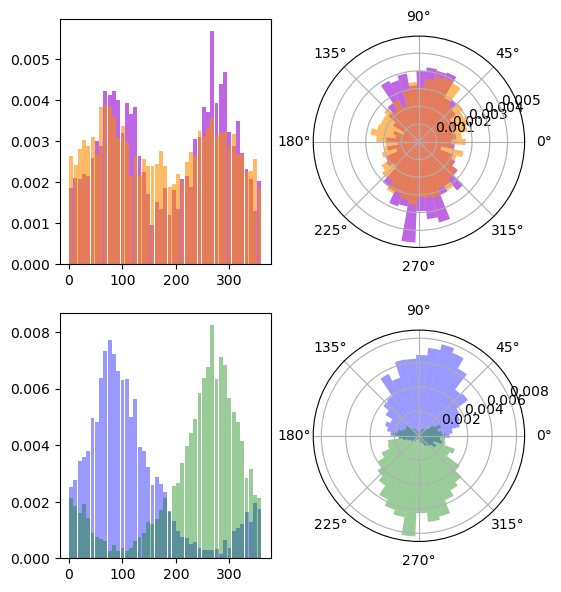

In [77]:
%matplotlib inline
df_all = df_fuse
dist = 30
bins_number = 45  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2*np.pi, bins_number+1)
width = 2 * np.pi / bins_number

y = (df_all["angp1_rel"]) % (2*np.pi)
y_close = (df_all["angp1_rel"][df_all["distance"]<dist]) % (2*np.pi)
y_far = (df_all["angp1_rel"][df_all["distance"]>dist]) % (2*np.pi)
y_up = (df_all["angp1_rel"][df_all["fuse_up"]]) % (2*np.pi)
y_down = (df_all["angp1_rel"][~df_all["fuse_up"]]) % (2*np.pi)

plt.figure(figsize=(6,7))
ax1 = plt.subplot(221)
ax2 = plt.subplot(222, projection='polar')
ax3 = plt.subplot(223)
ax4 = plt.subplot(224, projection='polar')

# p = ax1.hist(y, 60, alpha=.3, density=True, rwidth=.9)
p1,_,_ = ax1.hist(y_close*180/np.pi, 45, alpha=.6, density=True, rwidth=.9, color="darkviolet")
p2,_,_ = ax1.hist(y_far*180/np.pi, 45, alpha=.6, density=True, rwidth=.9, color="darkorange")
p3,_,_ = ax3.hist(y_up*180/np.pi, 45, alpha=.4, density=True, rwidth=.9, color="b")
p4,_,_ = ax3.hist(y_down*180/np.pi, 45, alpha=.4, density=True, rwidth=.9, color="g")


ax2.bar(bins[:bins_number], p1, color="darkviolet", width=width, bottom=0., alpha=.6, label="$dist<%s$" %dist)
ax2.bar(bins[:bins_number], p2, color="darkorange", width=width, bottom=0., alpha=.6, label="$dist>%s$" %dist)
ax4.bar(bins[:bins_number], p3, color="b", width=width, bottom=0., alpha=.4, label=r"$\langle \theta \rangle _{tr} > \pi$")
ax4.bar(bins[:bins_number], p4, color="g", width=width, bottom=0., alpha=.4, label=r"$\langle \theta \rangle _{tr} < \pi$")
# ax2.legend(bbox_to_anchor=(1.2, 1.1)); ax4.legend(bbox_to_anchor=(1.2, 1.1))

Text(0, 0.5, '$Angle$')

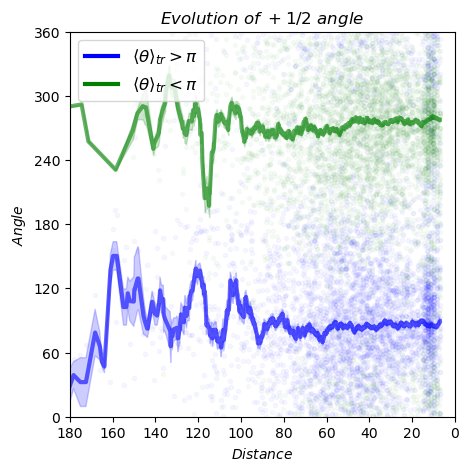

In [37]:
%matplotlib inline



fig, ax1 = plt.subplots(1,1,  figsize=(5,5))
ax1.plot(df_all.distance[df_all["fuse_up"]], df_all.angp1_rel[df_all["fuse_up"]]*180/np.pi % 360, ".b", alpha=.03)
ax1.plot(df_all.distance[~df_all["fuse_up"]], df_all.angp1_rel[~df_all["fuse_up"]]*180/np.pi % 360, ".g", alpha=.03)


win = 3

df = df_all[df_all["fuse_up"]]
df_av_up = plot_rolling_average(df, ax1, "angp1_rel", "distance", win=win, color="b")
df = df_all[~df_all["fuse_up"]]
df_av_down = plot_rolling_average(df, ax1, "angp1_rel", "distance", win=win, color="g")
ax1.plot([0,0],[0,0], "-b", linewidth=3, label=r"$\langle \theta \rangle _{tr} > \pi$")
ax1.plot([0,0],[0,0], "-g", linewidth=3, label=r"$\langle \theta \rangle _{tr} < \pi$")


plt.xlim([0,180]); 
plt.ylim([0,360]); 
plt.yticks(np.arange(0, 361, 60))
plt.gca().set_box_aspect(1); plt.gca().invert_xaxis()
plt.legend(fontsize=12); plt.title("$Evolution ~of ~+1/2 ~angle$")
plt.xlabel("$Distance$"); plt.ylabel("$Angle$")

## Relative angle between defects in a pair

Text(0.5, 1.0, '$Relative ~angle ~btw ~-1/2 ~and ~+1/2 ~defects$')

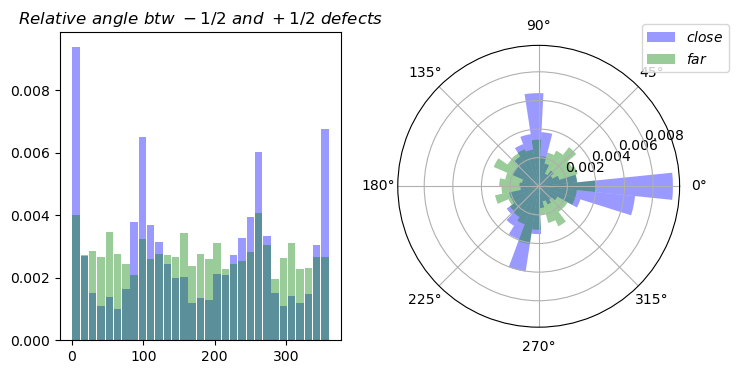

In [39]:
fig1 = plt.figure(figsize=(8,4))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')
bins_number = 31  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2*np.pi, bins_number+1) #* 180/np.pi
width = 2 * np.pi / bins_number
dist = 40

df_all = df_fuse

m_ang_all = []
for i in range(3):
    df_all["mp_angle"+str(i+1)]  = (df_all["angm"+str(i+1)] - df_all.angp1) % (2*np.pi)

mp_ang = []
mp_ang_all = []
mp_ang_all_far = []
mp_ang_up = []
mp_ang_down = []
for i in range(3):
    mp_ang.append(df_all["mp_angle"+str(i+1)].values)
    mp_ang_all.append(df_all["mp_angle"+str(i+1)][df_all["distance"]<dist].values)
    mp_ang_all_far.append(df_all["mp_angle"+str(i+1)][df_all["distance"]>60].values)
    mp_ang_up.append(df_all["mp_angle"+str(i+1)][(df_all.fuse_up)&(df_all["distance"]<dist)].values)
    mp_ang_down.append(df_all["mp_angle"+str(i+1)][~(df_all.fuse_up)&(df_all["distance"]<dist)].values)   

mp_ang_all = np.array(mp_ang_all)
mp_ang_all_far = np.array(mp_ang_all_far)
mp_ang_up = np.array(mp_ang_up)
mp_ang_down = np.array(mp_ang_down)
df_all["mp_angle_av"]= circmean(mp_ang, axis=0, low=0, high=2/3*np.pi)

p1,_,_ = ax1.hist(mp_ang_all.ravel() *180/np.pi, bins*180/np.pi, # 3 peaks
# p1,_,_ = ax1.hist(mp_ang_up.ravel() *180/np.pi, bins*180/np.pi, # 3 peaks
# p1,_,_ = ax1.hist(fuse_df["mp_angle_av"][fuse_df.fuse_up] *180/np.pi, bins*180/np.pi, # one peak
    alpha=.4, rwidth=.9, density=True, color="b")# ,  df.shape  
ax2.bar(bins[:bins_number], p1, color="b", width=width, bottom=0.0, alpha=.4,
    # label=r"$\langle \theta \rangle _{tr} < \pi$")
        label=r"$close$")

p2,_,_ = ax1.hist(mp_ang_all_far.ravel() *180/np.pi, bins*180/np.pi, # 3 peaks
# p2,_,_ = ax1.hist(mp_ang_down.ravel() *180/np.pi, bins*180/np.pi, # 3 peaks
# p2,_,_ = ax1.hist(fuse_df["mp_angle_av"][~fuse_df.fuse_up] *180/np.pi, bins*180/np.pi, # one peak
    alpha=.4, rwidth=.9, density=True, color="g")# ,  df.shape  
ax2.bar(bins[:bins_number], p2, color="g", width=width, bottom=0.0, alpha=.4,
    # label=r"$\langle \theta \rangle _{tr} > \pi$")
        label=r"$far$")

ax2.legend(bbox_to_anchor=(1.2, 1.1)); ax1.set_title(r"$Relative ~angle ~btw ~-1/2 ~and ~+1/2 ~defects$")

Text(0, 0.5, '$Angle ~(deg)$')

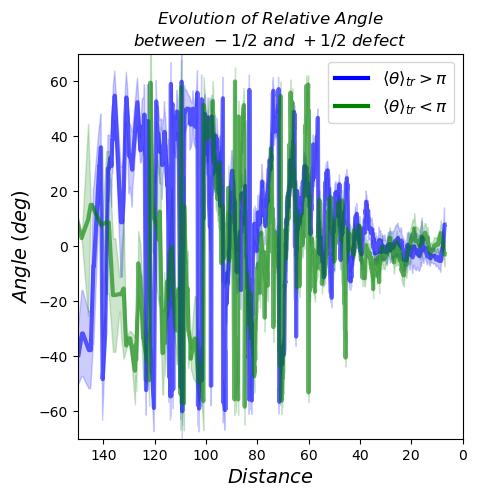

In [40]:
fig, ax1 = plt.subplots(1,1,  figsize=(5,5))

win = 1
# for i in range(3):
    # df_av_up = plot_rolling_average(fuse_df[fuse_df.fuse_up], ax1, "mp_angle"+str(i+1), "distance", win=win, color="b", low=-2/3*np.pi, high=0)
    # df_av_up = plot_rolling_average(fuse_df[~fuse_df.fuse_up], ax1, "mp_angle"+str(i+1), "distance", win=win, color="g", low=0*np.pi, high=2/3*np.pi)


# ax1.plot(df_all.distance[fuse_df.fuse_up], (df_all.mp_angle_av[fuse_df.fuse_up] % (2/3*np.pi) - (1/3*np.pi))*180/np.pi, "ob", alpha=.05)
# ax1.plot(df_all.distance[~fuse_df.fuse_up], (df_all.mp_angle_av[~fuse_df.fuse_up] % (2/3*np.pi) - (1/3*np.pi))*180/np.pi, "og", alpha=.05)

df_av_up = plot_rolling_average(df_all[df_all.fuse_up], ax1, "mp_angle_av", "distance", win=win, color="b", low=-1/3*np.pi, high=1/3*np.pi)
df_av_up = plot_rolling_average(df_all[~df_all.fuse_up], ax1, "mp_angle_av", "distance", win=win, color="g", low=-1/3*np.pi, high=1/3*np.pi)

ax1.plot([0,0],[0,0], "-b", linewidth=3, label=r"$\langle \theta \rangle _{tr} > \pi$")
ax1.plot([0,0],[0,0], "-g", linewidth=3, label=r"$\langle \theta \rangle _{tr} < \pi$")


plt.xlim([150,0]); plt.ylim([-70, 70]); #plt.yticks(np.arange(0, 121, 30))
plt.gca().set_box_aspect(1); #plt.gca().invert_xaxis()  
plt.legend(fontsize=12); 
plt.title(r"$Evolution ~of ~Relative ~Angle$" +"\n" + r"$between ~-1/2 ~and ~+1/2 ~defect$")
plt.xlabel(r"$Distance$", fontsize=14); plt.ylabel(r"$Angle ~(deg)$", fontsize=14)    

(6.239852330828614, 0.09798898207457711)

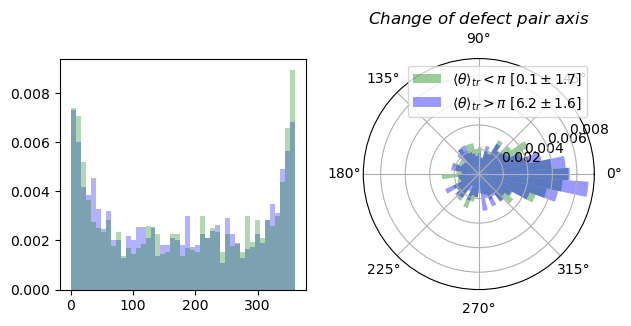

In [41]:
%matplotlib inline
diff_period = 2
dist = 30
bins_number = 45  # the [0, 360) interval will be subdivided into this
# number of equal bins
bins = np.linspace(0, 2*np.pi, bins_number+1)
width = 2 * np.pi / bins_number

df_all = df_fuse

# (df_all["mp_angle"][(df_all.fuse_up) & (df_all.distance<40)].diff() % 2*np.pi).hist(alpha=.6)
# (df_all["mp_angle"][~(df_all.fuse_up) & (df_all.distance<40)].diff() % 2*np.pi).hist(alpha=.6)

dtheta_up = df_all["mp_angle"][(df_all.fuse_up) & (df_all.distance<dist)].diff(periods=diff_period).dropna() % (2*np.pi)
dtheta_down = df_all["mp_angle"][(~df_all.fuse_up) & (df_all.distance<dist)].diff(periods=diff_period).dropna() % (2*np.pi)

fig1 = plt.figure(figsize=(7,3))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')

p1,_,_ = ax1.hist(dtheta_up*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=1., alpha=.3, color="b")
p2,_,_ = ax1.hist(dtheta_down*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=1., alpha=.3, color="g")

ax2.bar(bins[:bins_number], p1, color="green", width=width, bottom=0.0, alpha=.4,
        label=r"$\langle \theta \rangle _{tr} < \pi ~[%.1f  \pm%.1f]$" 
        %(circmean(dtheta_up), circstd(dtheta_up)))
ax2.bar(bins[:bins_number], p2, color="blue", width=width, bottom=0.0, alpha=.4,
        label=r"$\langle \theta \rangle _{tr} > \pi ~[%.1f  \pm%.1f]$" 
        %(circmean(dtheta_down), circstd(dtheta_down)))

ax2.legend(loc='upper right')
ax2.set_title(r"$Change ~of ~defect ~pair ~axis$")

circmean(dtheta_down, low=0, high=2*np.pi), circmean(dtheta_up, low=0, high=2*np.pi)

Text(0, 0.5, '$\\Delta \\theta, ~Angle ~change ~(deg)$')

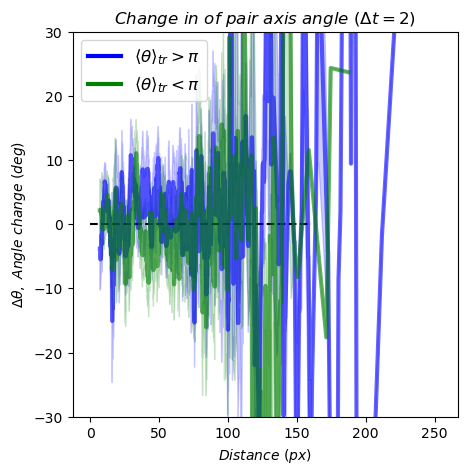

In [42]:
%matplotlib inline
win = 1
df = df_all.copy().set_index("distance")

dtheta_up = df["mp_angle"][df.fuse_up].diff(periods=diff_period).dropna()# % (2*np.pi)
dtheta_up = dtheta_up.reset_index()
dtheta_down = df["mp_angle"][~df.fuse_up].diff(periods=diff_period).dropna()
dtheta_down = dtheta_down.reset_index()

fig, ax1 = plt.subplots(1,1,  figsize=(5,5))
ax1.plot([0,160], [0,0], "--k", alpha=1)
# ax1.plot(dtheta_up.distance, (dtheta_up.mp_angle)*180/np.pi, "ob", alpha=.05)
# ax1.plot(dtheta_down.distance, (dtheta_down.mp_angle)*180/np.pi, "og", alpha=.05)

ax1.plot([0,0],[0,0], "-b", linewidth=3, label=r"$\langle \theta \rangle _{tr} > \pi$")
ax1.plot([0,0],[0,0], "-g", linewidth=3, label=r"$\langle \theta \rangle _{tr} < \pi$")

df_av_up = plot_rolling_average(dtheta_up, ax1, "mp_angle", "distance", win=win, color="b", low=-np.pi, high=np.pi)
df_av_down = plot_rolling_average(dtheta_down, ax1, "mp_angle", "distance", win=win, color="g", low=-np.pi, high=np.pi)

# ax1.invert_xaxis()
ylim = 30
ax1.set_box_aspect(1) 
ax1.set_ylim([-ylim,ylim])
# ax1.set_xlim([140,0])
plt.legend(fontsize=12); plt.title(r"$Change ~in ~of ~pair ~axis ~angle ~(\Delta t=%s)$" % diff_period)
plt.xlabel("$Distance ~(px)$"); plt.ylabel(r"$\Delta \theta, ~Angle ~change ~(deg)$")

In [33]:
min_dist, max_dist = 20, 70
print("average angle change: \n UP=%.2f | DOWN=%.2f" % (
    df_av_up.mp_angle_ave[(df_av_up.distance<max_dist)&(df_av_up.distance>min_dist)].mean(),
    df_av_down.mp_angle_ave[(df_av_down.distance<max_dist)&(df_av_down.distance>min_dist)].mean()
    ))

average angle change: 
 UP=0.87 | DOWN=-1.72


## Fit fusion-creation mean trajectories

In [43]:
mean_fusion = plot_rolling_average(df_fuse,ax1, "distance", "track_frame", win=1.5, show=False, avfunc=np.mean, stdfunc=np.std)
mean_creation = plot_rolling_average(df_cr,ax1, "distance", "track_frame", win=1.5, show=False, avfunc=np.mean, stdfunc=np.std)

means = {"fusion": mean_creation.groupby("track_frame").mean().distance_ave, "creation": mean_creation.groupby("track_frame").mean().distance_ave}

C:\Users\victo\AppData\Local\Temp\ipykernel_5244\1532595957.py:9: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  "fusion": mean_fusion.groupby("track_frame").mean().distance_ave[-num_of_frames:],


FUSION
slope: -5.766022102263814 | intercept: 17.584641957288383
Y=0 @ X=: 3.049700754768947
CREATION
slope: 5.722124455349193 | intercept: 23.391824750007586
Y=0 @ X=: -4.0879615486413075


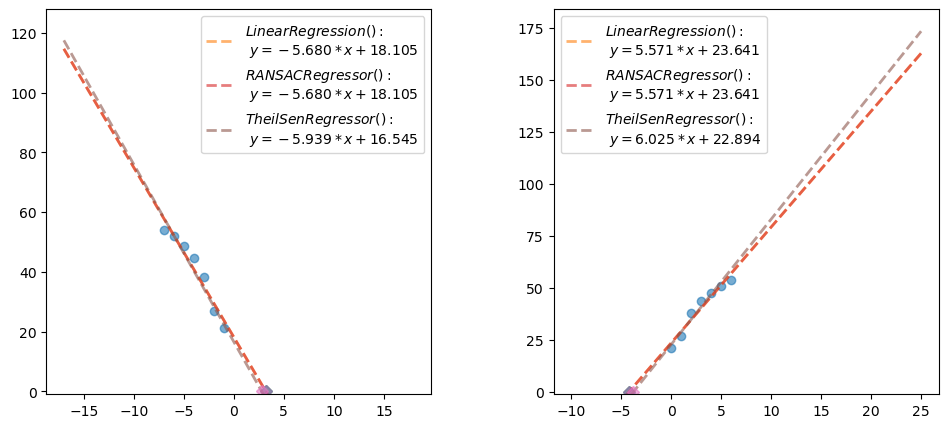

In [44]:
%matplotlib inline
from sklearn import linear_model

mean_fusion = plot_rolling_average(df_fuse,ax1, "distance", "track_frame", win=1.5, show=False, avfunc=np.mean, stdfunc=np.std)
mean_creation = plot_rolling_average(df_cr,ax1, "distance", "track_frame", win=1.5, show=False, avfunc=np.mean, stdfunc=np.std)

num_of_frames = 7
means = {
    "fusion": mean_fusion.groupby("track_frame").mean().distance_ave[-num_of_frames:], 
    "creation": mean_creation.groupby("track_frame").mean().distance_ave[:num_of_frames]
         }


fig, axs = plt.subplots(1,2,  figsize=(12,5))
axs = axs.ravel()

lrs = (
    linear_model.LinearRegression(), 
    linear_model.RANSACRegressor(), 
    linear_model.TheilSenRegressor()
    )

slope_intercept = {}

for ax, (name, mean) in zip(axs, means.items()):
    
    ave_slope, ave_intercept = 0, 0
    y = mean
    X = np.arange(len(mean))

    if name=="fusion":
        X = X - y.shape[0]

    ax.plot(X, y, "o", alpha=.6)

    for lr in lrs:
        lr.fit(X.reshape(-1, 1), y)
        try:
            slope = lr.estimator_.coef_[0]
            intercept = lr.estimator_.intercept_
        except:
            slope = lr.coef_[0]
            intercept = lr.intercept_

        # prdict for line
        line_X = np.arange(X.min()-10, X.max()+20)[:, np.newaxis]
        line_y = lr.predict(line_X)

        ax.plot(line_X, line_y, "--", linewidth=2, alpha=.6,
                label="$%s:$\n $y= %.3f *x + %.3f$" %(lr, slope, intercept))   
        ax.plot(-intercept/slope, 0, "D", alpha=.6,)        
        ave_slope += slope  
        ave_intercept += intercept

    # use prints to set the SLOPE and INTERCEP globals in the next cell
    print(name.upper())
    print('slope:', ave_slope/len(lrs), '| intercept:', ave_intercept/len(lrs))
    print('Y=0 @ X=:', -ave_intercept/ave_slope)
    slope_intercept[name] = {"slope": ave_slope/len(lrs), "intercept": ave_intercept/len(lrs)}


    ax.set_box_aspect(1)
    ax.set_ylim([-1,None])

    ax.legend(loc='upper left')
    if name=="fusion":
        ax.legend(loc='upper right')
    # break

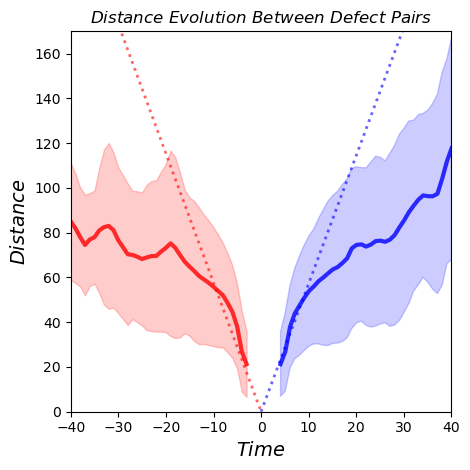

In [45]:
%matplotlib inline
SAVE = False
# FUSION
slope_fusion, intercept_fusion = slope_intercept["fusion"]["slope"], slope_intercept["fusion"]["intercept"] #-2.0 , 23.72
fusion_tshift = intercept_fusion/slope_fusion

fusion = mean_fusion.groupby("track_frame").mean().reset_index()

plt.plot(fusion.track_frame + fusion_tshift, fusion.distance_ave, "r-", alpha=.8, linewidth=3,)
    # label="# of fused pairs: %s" % (mp_distance_fusion_mat.shape[0]))
plt.fill_between(fusion.track_frame + fusion_tshift, 
                 fusion.distance_ave-fusion.distance_std, 
                 fusion.distance_ave+fusion.distance_std, 
                 color="red", alpha=.2)
trange = 40
xfit = np.array([-trange,0])
plt.plot(xfit, slope_fusion * xfit, linestyle="dotted", color="red", alpha=.6, linewidth=2)

# # CREATION
slope_creation, intercept_creation =  slope_intercept["creation"]["slope"], slope_intercept["creation"]["intercept"]#2.98, 27.25
creation_tshift = - intercept_creation/slope_creation

creation = mean_creation.groupby("track_frame").mean().reset_index()

plt.plot(creation.track_frame - creation_tshift, creation.distance_ave, "b-", alpha=.8, linewidth=3,)
plt.fill_between(creation.track_frame - creation_tshift, 
                 creation.distance_ave-creation.distance_std, 
                 creation.distance_ave+creation.distance_std, 
                 color="blue", alpha=.2)

xfit = np.array([0,trange])
plt.plot(xfit, slope_creation * xfit, linestyle="dotted", color="b", alpha=.6, linewidth=2,
    )
# lim = 40
# plt.ylim([0,None])
# plt.xlim([-lim,lim])
plt.gca().set_box_aspect(1); plt.xlim([-trange,trange]); plt.ylim([0,170])
plt.xlabel(r'$Time$', fontsize=14)
plt.ylabel(r'$Distance$', fontsize=14) #plt.ylabel('$Distance ~(\mu m)$')
plt.title(r'$Distance ~Evolution ~Between ~Defect ~Pairs$')
plt.tight_layout()
# plt.legend()

In [34]:
def cofidence_range(X,y):
    import statsmodels.api as sm
    alpha = 0.05 # 95% confidence interval
    lr = sm.OLS(y, sm.add_constant(X)).fit()
    conf_interval = lr.conf_int(alpha)
    print("slope 95% CI ", "[%.2f, %.2f]" % (conf_interval[1][0], conf_interval[1][1]))    


for name, mean in means.items():
    y = mean
    X = np.arange(len(mean))
    print(name.upper())
    cofidence_range(X,y)

# Output of conf_interval
#  lower upper
# [-1.234 0.765]
# [-0.345 0.154]
# This means that we are 95% confident that the true value of the first parameter is between -1.234 and 0.765, 
# and we are 95% confident that the true value of the second parameter is between -0.345 and 0.154.

FUSION
slope 95% CI  [41.63, -3.32]
CREATION
slope 95% CI  [19.44, 5.12]


## Average velocity on defects

In [1]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
import pickle 
import os
import sys
import pandas as pd
from joblib import Parallel, delayed

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

minimal_track = 3
image_list_path = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\ISF defects new\6"
track_path = r"C:\Users\victo\OneDrive - BGU\Dov\PlusAndMinusTM6.csv"


image_list = glob.glob(image_list_path + "/*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())

plus_minus_df = pd.read_csv(track_path).dropna(subset='TRACK_ID')
plus_minus_df = plus_minus_df.groupby('TRACK_ID').filter(lambda x : len(x)>minimal_track).copy()
df_plus = pd.DataFrame()
df_minus = pd.DataFrame()
df_plus[['TRACK_ID','xp', 'yp', 'angp1','FRAME']] = plus_minus_df[['TRACK_ID','x_img','y_img','ang1','FRAME']][plus_minus_df.charge==.5].copy()
df_minus[['TRACK_ID','xm', 'ym', 'angm1','FRAME']] = plus_minus_df[['TRACK_ID','x_img','y_img','ang1','FRAME']][plus_minus_df.charge==-.5].copy()
print("Number of plus tracks: %s" %df_plus.shape[0])
print("Number of minus tracks: %s" %df_minus.shape[0])

Number of plus tracks: 119628
Number of minus tracks: 117470


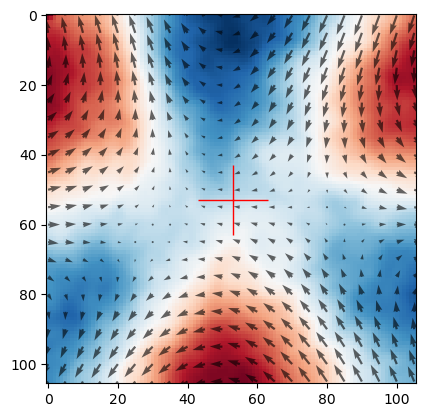

In [5]:
frames = np.arange(0, 200)
uv = []
# for frame in frames:
#     uv.append(defect_flow_frame_all_frames(
#         cv2.imread(image_list[frame])[:,:,0],
#         cv2.imread(image_list[frame+1])[:,:,0],
#         df_plus[df_plus.FRAME==frame], defect_type="plus",
#         # df_minus[df_minus.FRAME==frame], defect_type="minus",
#         ))

box = 150
uv = Parallel(n_jobs=5)(delayed(defect_flow_frame_all_frames)(
    cv2.imread(img1)[:,:,0],
    cv2.imread(img2)[:,:,0], 
    # df_plus[df_plus.FRAME==frame], defect_type="plus",
    df_minus[df_minus.FRAME==frame], defect_type="minus",
    box=(int(box),int(box)),
    # filt=5
    ) for frame,img1,img2 in zip(frames, image_list[frames[0]:frames[-2]], image_list[frames[1]:frames[-1]]))


uu, vv, ids  = [], [], []
for i in range(len(uv)):
    uu += uv[i][0]  # concatenate the elements from all frames
    vv += uv[i][1]
    ids += uv[i][2]

step = 5
vscale = 10
field1 = np.stack((np.mean(uu, axis=0), np.mean(vv, axis=0)), axis=-1)
y, x = np.mgrid[0:field1.shape[0], 0:field1.shape[1]] 
vorticity1 = gaussian_filter(curl_npgrad(field1), sigma=1)
plt.imshow(vorticity1, cmap='RdBu', vmin=-vorticity1.max(), vmax=vorticity1.max())
plt.quiver(x[::step, ::step], y[::step, ::step], 
          field1[::step, ::step,0], -field1[::step, ::step,1],  color='k',
          width=.006, scale=vscale, alpha=.6
          )
xcnt, ycnt = uu[0].shape[0]//2, uu[0].shape[1]//2
plt.plot(xcnt, ycnt, "+r", markersize=50)

In [28]:
def find_unique_values_with_indexes(ids):
    unique_values = {}
    for index, value in enumerate(ids):
        if value not in unique_values:
            unique_values[value] = []
        unique_values[value].append(index)
    
    return unique_values

# TODO add Frame number 
unique_values_with_indexes = find_unique_values_with_indexes(ids)
print(unique_values_with_indexes)

{4.0: [0, 117, 278, 438, 580, 637, 867, 934, 1518, 1558, 1693], 5.0: [1, 115, 277, 440, 579, 639, 869, 935], 6.0: [2, 125, 453, 592, 648, 875, 943, 1033], 7.0: [3, 118, 279], 8.0: [4, 121, 281, 442], 9.0: [5, 131, 284, 441, 586, 647, 872, 939, 1311, 1524, 1566, 1702, 1836, 1966], 10.0: [6, 127, 287, 449, 593, 761, 954, 1038, 1221, 1330, 1541, 1583, 1715, 1852, 1975, 2102, 2215, 2344, 2507], 11.0: [7, 122, 285, 444, 584, 640, 870, 942], 12.0: [8, 126, 293, 448, 590, 650, 883, 953, 1040, 1222, 1328, 1542, 1580, 1716, 1849, 1976, 2104, 2218, 2342, 2508, 2643, 2685, 2800, 3004, 3036, 3144, 3240, 3362, 3475, 3573, 3756, 3908, 3986, 4128, 4214, 4310, 4510, 4625, 4762, 4882, 5000, 5115], 13.0: [9, 120, 283, 447, 583, 641, 868, 937, 1026, 1205, 1314, 1522, 1561, 1699, 1829, 1953, 2085, 2315, 2325, 2488, 2625], 14.0: [10, 128, 291, 450, 588, 655, 950, 1037, 1213], 15.0: [11, 129, 290, 455, 595, 652, 757, 961, 1044, 1217, 1327, 1540, 1579, 1714, 2103, 2339], 16.0: [12, 136, 299, 460, 601, 664, 7

In [13]:
ids = np.array(ids)
unique_id = np.unique(ids)
vort_mean = np.zeros_like(unique_id)
for id in unique_id:
    if id==unique_id[0]:
        gaussian_filter(curl_npgrad(np.stack((ui, vi), axis=-1)),sigma=5).mean()
        

SyntaxError: unexpected EOF while parsing (4023514325.py, line 2)

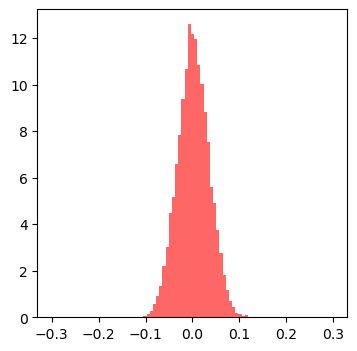

In [6]:
vort_mean = [gaussian_filter(curl_npgrad(np.stack((u, v), axis=-1)),sigma=5).mean() for u, v in zip(uu,vv)]
# plt.plot(np.arange(len(vort_mean)), vort_mean,".", alpha=.1)
fig, ax = plt.subplots(1,1, figsize=(4,4))
_ = ax.hist(vort_mean, bins=np.linspace(-.3,.3, 90), alpha=.6, color="r", density=True)

In [60]:
len(vv), len(uv), uu[0].shape[1]//2

(56446, 498, 17)

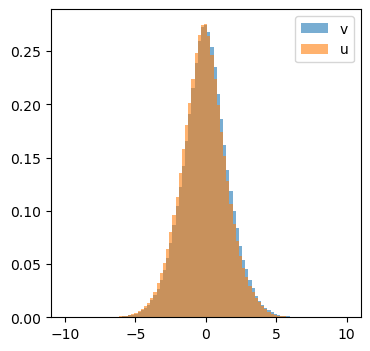

In [7]:
bins = np.linspace(-10, 10, 90)
xcnt, ycnt = uu[0].shape[0]//2, uu[0].shape[1]//2
dd = 10

fig, ax = plt.subplots(1,1, figsize=(4,4))
ax.hist(np.array(vv)[:,ycnt-dd:ycnt+dd, xcnt-dd:xcnt+dd].ravel(), 
        bins=bins, alpha=.6, rwidth=1., density=True
        )
ax.hist(np.array(uu)[:,ycnt-dd:ycnt+dd, xcnt-dd:xcnt+dd].ravel(), 
        bins=bins, alpha=.6, rwidth=1.,
        density=True)
plt.legend(["v","u"])

In [ ]:
import seaborn as sns
df = pd.DataFrame({"u": np.array(uu)[:,ycnt-dd:ycnt+dd, xcnt-dd:xcnt+dd].ravel(),
                   "v": np.array(vv)[:,ycnt-dd:ycnt+dd, xcnt-dd:xcnt+dd].ravel()})
sns.kdeplot(data=df, x="u", y="v", levels=20, alpha=.6, fill=True)


212 212


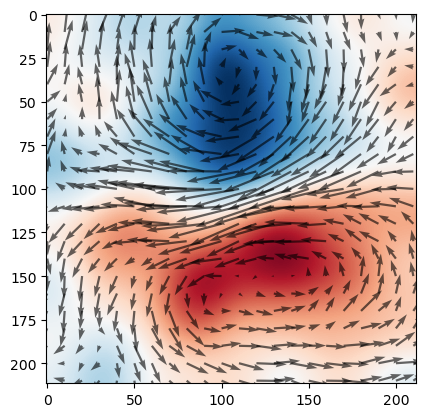

In [96]:
frame = 600
uv = defect_flow_frame_average1(
    cv2.imread(image_list[frame])[:,:,0],
    cv2.imread(image_list[frame+1])[:,:,0],
    df_plus[df_plus.FRAME==frame], defect_type="plus",
    # df_minus[df_minus.FRAME==frame], defect_type="minus",
    )

step = 10
vscale = 10
field1 = np.stack((np.sum(uv[0], axis=0), np.sum(uv[1], axis=0)), axis=-1)/uv[-1]
y, x = np.mgrid[0:field1.shape[0], 0:field1.shape[1]] 
vorticity1 = gaussian_filter(curl_npgrad(field1), sigma=15)
plt.imshow(vorticity1, cmap='RdBu', vmin=-vorticity1.max(), vmax=vorticity1.max())
plt.quiver(x[::step, ::step], y[::step, ::step], 
          field1[::step, ::step,0], -field1[::step, ::step,1],  color='k',
          width=.006, scale=vscale, alpha=.6
          )

In [84]:
np.sum(uv[0], axis=0).shape

(212, 212, 2)

In [ ]:
box = 250

img_width = cv2.imread(image_list[0]).shape[1]
first_frame = 60
last_frame = 100 #first_frame + len(image_list[first_frame:]) - 1
print(image_list[last_frame])
print("Total length: %s" % len(image_list[first_frame+1:last_frame]))

u_v_countA = Parallel(n_jobs=-1)(delayed(defect_flow_frame_average1)(
    # --- LEFT ----
    cv2.imread(img1)[:,:,0],cv2.imread(img2)[:,:,0], 
    # all_pairs_df[(all_pairs_df.index==frame)&(all_pairs_df.xp<900)], 
    # --- RIGHT ---
    # all_pairs_df[(all_pairs_df.index==frame)&(all_pairs_df.xp>900)],
    # df_plus[(df_plus.FRAME==frame)&(df_plus.xp>900)],
    df_plus[df_plus.FRAME==frame],
    defect_type="all", 
    box=(int(box),int(box)),
    filt=1
    ) for (frame,img1),img2 in zip(enumerate(image_list[first_frame:last_frame-1]),image_list[first_frame+1:last_frame]))


u_ups, v_ups, count_ups = [], [], []
for q in u_v_countA:
    if q:
        u_ups.append(q[0])
        v_ups.append(q[1])
        count_ups.append(q[2])
u_ups = np.array(u_ups)
v_ups = np.array(v_ups)
count_ups = np.array(count_ups)  

C:\Users\victo\Downloads\SB_lab\BEER_DATA\ISF defects new\6\6_X101.tif
Total length: 39


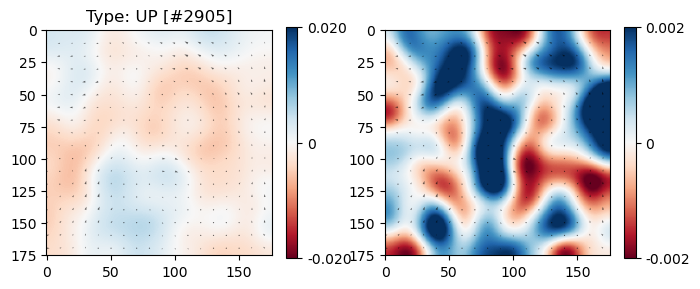

In [41]:
%matplotlib inline
n, m = 0,-1 #800,900 #600,800 #450,550 #150,250 #50,150
u_up = np.average(u_ups[count_ups!= 0][n:m,:,:], axis=0, weights=count_ups[count_ups!= 0][n:m])
v_up = np.average(v_ups[count_ups!= 0][n:m,:,:], axis=0, weights=count_ups[count_ups!= 0][n:m])

filt = 10
step = 10
vscale = 10
vort_mag, div_mag = .02, .002

fig, axs = plt.subplots(1,2, figsize=(8,3))
# for ax in axs.ravel(): ax.axis('off')
ax1,ax2 = axs.ravel()

field1 = np.stack((u_up, v_up), axis=-1)
y, x = np.mgrid[0:u_up.shape[0], 0:u_up.shape[1]] 
vorticity1 = gaussian_filter(curl_npgrad(field1), sigma=filt)
c1 = ax1.imshow(vorticity1, cmap='RdBu', vmin=-vort_mag, vmax=vort_mag)
ax1.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=vscale, alpha=.6)
ax1.set_title("Type: %1s [#%1d]" % ("UP", np.sum(count_ups)))

divergence = gaussian_filter(divergence_npgrad(field1), sigma=filt)
c2 = ax2.imshow(divergence, cmap='RdBu', vmin=-div_mag, vmax=div_mag)
ax2.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=vscale, alpha=.6)


# Add colorbar, make sure to specify tick locations to match desired ticklabels
import matplotlib.ticker as mticker
ticks_vort, ticks_div = [-vort_mag, 0, vort_mag], [-div_mag, 0, div_mag]
for c,ticks in zip([c1,c2], [ticks_vort,ticks_div,ticks_vort,ticks_div]):
    fig.colorbar(c, ticks=ticks, format=mticker.FixedFormatter(("%.3f,%.0f,%.3f" % tuple(ticks)).split(',')))

# fig.savefig(save_folder + "/vortex around defects_N500.svg")
# fig.savefig(r"C:\Users\victo\OneDrive - BGU\BEER\DefectInter paper\Images\bacteria av flow create down 500.svg")

## Unused codes below !!!!

In [180]:
ori, plushalf, minushalf = analyze_defects(cv2.imread(image_list[f-1])[:,:,0], 
                                           sigma=11)

In [27]:
%matplotlib qt

ori_map = False

# Apply Contrast Limited Adaptive Histogram Equalization
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

image_list = glob.glob(r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\ISF defects new\6\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())

df = df_fuse # df_cr
grouped_df = df_cr.groupby(['plus_id','min_id'])['FRAME'].min().reset_index()
df_i = grouped_df.merge(df_cr[['plus_id', 'min_id', 'FRAME', 'xp', 'yp', 'xm', 'ym']], 
                          on=['plus_id', 'min_id', 'FRAME'], 
                          how='left')
grouped_df = df_fuse.groupby(['plus_id','min_id'])['FRAME'].max().reset_index()
df_f = grouped_df.merge(df_fuse[['plus_id', 'min_id', 'FRAME', 'xp', 'yp', 'xm', 'ym']], 
                          on=['plus_id', 'min_id', 'FRAME'], 
                          how='left')

frames = np.sort(df["FRAME"].unique())
white_frame = np.ones_like(cv2.imread(image_list[0]))[:,:,:]
[height, width, _] = white_frame.shape

# fig, [ax1,ax] = plt.subplots(2,1, figsize=(width//100, height//50))
fig, ax = plt.subplots(1,1, figsize=(width//100, height//100))
plt.gca().set_aspect('equal')
extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
sigma = 11

for f_num,f in enumerate(frames[:]):

    pair_f = df[df.FRAME==f]
    # cr = df_i[df_i.FRAME==f]
    cr = df_f[df_f.FRAME==f]
    
    alpha_half, scale_half = .2, 40   
    ax.clear(); #ax.set_axis_off()

    img = cv2.imread(image_list[f-1])[:,:,0]
    img_clahe = clahe.apply(img)
    ax.imshow(255-img_clahe, "gray")
    ax.invert_yaxis()
    # break
    # ax.imshow(cv2.imread(image_list[f]), "gray")
    
    if ori_map:
        ori, plushalf, minushalf = analyze_defects(cv2.imread(image_list[f-1])[:,:,0], 
                                            sigma=sigma)
        s = int(1.* sigma)
        x = np.arange(0, img.shape[1], s)
        y = np.arange(0, img.shape[0], s)
        ax.quiver(x,y,
                np.cos(ori)[::s,::s], -np.sin(ori)[::s,::s], 
                headaxislength=0, headwidth=0, headlength=0, 
                color='g', scale=20, pivot='mid', alpha=.8)

        alpha_half, scale_half = .6, 30    
        ax.plot(plushalf['x'], plushalf['y'],'ro',markersize=6, alpha=.6)
        ax.quiver(plushalf['x'], plushalf['y'], 
            np.cos(plushalf['ang1']), np.sin(plushalf['ang1']), 
            headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

        ax.plot(minushalf['x'], minushalf['y'],'bo',markersize=6, alpha=.6)
        for j in range(3):
            ax.quiver(minushalf['x'], minushalf['y'], 
                np.cos(minushalf['ang'+str(j+1)]), np.sin(minushalf['ang'+str(j+1)]), 
                headaxislength=0, headwidth=0, headlength=0, color='b', scale=scale_half, alpha=alpha_half)
        # break        

    if ~cr.empty:
        ax.plot(cr['xp'], cr['yp'],'m.',markersize=40, alpha=.2)
        # break

    ax.plot(pair_f['xp'], pair_f['yp'],'r.',markersize=8, alpha=alpha_half)
    ax.quiver(pair_f['xp'], pair_f['yp'], 
        np.cos(pair_f['angp1']), np.sin(pair_f['angp1']), 
        headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

    # ax.plot(pair_f['xm'], pair_f['ym'],'b.',markersize=8, alpha=alpha_half)
    for i in range(3):
        ax.quiver(pair_f['xm'], pair_f['ym'], 
            np.cos(pair_f['angm'+str(i+1)]), np.sin(pair_f['angm'+str(i+1)]), 
            headaxislength=0, headwidth=0, headlength=0, color='b', scale=scale_half, alpha=alpha_half)  

    save_path = os.path.join(
        os.path.dirname(image_list[0]),
        'Defects',
        'Nematic_fuse',
        'frame_' + str(f) + ".png"
        )
    # break
    ax.set_xlim([0, width])
    ax.set_ylim([0, height])
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, bbox_inches=extent.expanded(1.15, 1.15))

    progressBar(f_num, len(frames))
    
    if f_num>400:
        break

In [4]:
plus_minus_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_HBEC_s2.csv").dropna(subset=["min_id","creation"])
plus_minus_df = plus_minus_df.groupby('plus_id').filter(lambda x : len(x)>3).copy()
df_plus = pd.DataFrame()
df_minus = pd.DataFrame()
df_plus[['xp', 'yp', 'angp1','FRAME']] = plus_minus_df[['xp','yp','angp1','FRAME']][~plus_minus_df.fuse_up & plus_minus_df.fusion].copy()
df_minus[['xm', 'ym', 'angm1','FRAME']] = plus_minus_df[['xm','ym','angm1','FRAME']][~plus_minus_df.fuse_up & plus_minus_df.fusion].copy()

minushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)\Defects\MinusHalf1.csv")
plushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)\Defects\PlusHalf1.csv")

first_frame = np.max([minushalf_df["frame"].min(), plushalf_df["frame"].min()]) # Validate this number in image folders
last_frame = np.min([minushalf_df["frame"].max(), plushalf_df["frame"].max()])   # Validate this number in image folders

image_list_all = glob.glob(r"C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)\Raw\*.tif")
image_list_all = natsorted(image_list_all, key=lambda y: y.lower())
image_list = image_list_all[first_frame-1:last_frame:1]

print(first_frame, last_frame, "\n", image_list[0], "\n", image_list[-1])

161 500 
 C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)\Raw\Trans__161.tif 
 C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)\Raw\Trans__500.tif


In [11]:
%matplotlib qt

ori_map = True

# Apply Contrast Limited Adaptive Histogram Equalization
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

image_list_all = glob.glob(r"C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)\Raw\*.tif")
image_list_all = natsorted(image_list_all, key=lambda y: y.lower())
image_list = image_list_all[first_frame-1:last_frame:1]

df = df_cr # df_cr
grouped_df = df_cr.groupby(['plus_id','min_id'])['FRAME'].min().reset_index()
df_i = grouped_df.merge(df_cr[['plus_id', 'min_id', 'FRAME', 'xp', 'yp', 'xm', 'ym']], 
                          on=['plus_id', 'min_id', 'FRAME'], 
                          how='left')
grouped_df = df_fuse.groupby(['plus_id','min_id'])['FRAME'].max().reset_index()
df_f = grouped_df.merge(df_fuse[['plus_id', 'min_id', 'FRAME', 'xp', 'yp', 'xm', 'ym']], 
                          on=['plus_id', 'min_id', 'FRAME'], 
                          how='left')

frames = np.sort(df["FRAME"].unique())
white_frame = np.ones_like(cv2.imread(image_list[0]))[:,:,:]
[height, width, _] = white_frame.shape

# fig, [ax1,ax] = plt.subplots(2,1, figsize=(width//100, height//50))
fig, ax = plt.subplots(1,1, figsize=(width//100, height//100))
plt.gca().set_aspect('equal')
extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
sigma = 25

for f_num,f in enumerate(frames[:]):

    pair_f = df[df.FRAME==f]
    cr = df_i[df_i.FRAME==f]
    # cr = df_f[df_f.FRAME==f]
    
    alpha_half, scale_half = .4, 30   
    ax.clear(); #ax.set_axis_off()

    img = cv2.imread(image_list[f-1])[:,:,0]
    img_clahe = clahe.apply(img)
    ax.imshow(255-img_clahe, "gray")
    ax.invert_yaxis()
    # break
    # ax.imshow(cv2.imread(image_list[f]), "gray")
    
    if ori_map:
        ori, plushalf, minushalf = analyze_defects(cv2.imread(image_list[f-1])[:,:,0], 
                                            sigma=sigma)
        s = int(1.* sigma)
        x = np.arange(0, img.shape[1], s)
        y = np.arange(0, img.shape[0], s)
        ax.quiver(x,y,
                np.cos(ori)[::s,::s], -np.sin(ori)[::s,::s], 
                headaxislength=0, headwidth=0, headlength=0, 
                color='g', scale=20, pivot='mid', alpha=.8)

        # alpha_half, scale_half = .6, 30    
        # ax.plot(plushalf['x'], plushalf['y'],'ro',markersize=6, alpha=.6)
        # ax.quiver(plushalf['x'], plushalf['y'], 
        #     np.cos(plushalf['ang1']), np.sin(plushalf['ang1']), 
        #     headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

        # ax.plot(minushalf['x'], minushalf['y'],'bo',markersize=6, alpha=.6)
        # for j in range(3):
        #     ax.quiver(minushalf['x'], minushalf['y'], 
        #         np.cos(minushalf['ang'+str(j+1)]), np.sin(minushalf['ang'+str(j+1)]), 
        #         headaxislength=0, headwidth=0, headlength=0, color='b', scale=scale_half, alpha=alpha_half)
        # break        

    if ~cr.empty:
        ax.plot(cr['xp'], cr['yp'],'m.',markersize=40, alpha=.2)
        # break

    ax.plot(pair_f['xp'], pair_f['yp'],'r.',markersize=8, alpha=alpha_half)
    ax.quiver(pair_f['xp'], pair_f['yp'], 
        np.cos(pair_f['angp1']), np.sin(pair_f['angp1']), 
        headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

    # ax.plot(pair_f['xm'], pair_f['ym'],'b.',markersize=8, alpha=alpha_half)
    for i in range(3):
        ax.quiver(pair_f['xm'], pair_f['ym'], 
            np.cos(pair_f['angm'+str(i+1)]), np.sin(pair_f['angm'+str(i+1)]), 
            headaxislength=0, headwidth=0, headlength=0, color='b', scale=scale_half, alpha=alpha_half)  

    save_path = os.path.join(
        os.path.dirname(image_list[0]),
        'Defects',
        'Nematic_cr',
        'frame_' + str(f) + ".png"
        )
    # break
    ax.set_xlim([0, width])
    ax.set_ylim([0, height])
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    # fig.savefig(save_path, bbox_inches=extent.expanded(1.15, 1.15))

    progressBar(f_num, len(frames))
    
    if f_num>1:
        break